In [2]:
#%pip install scipy
#%pip install tensorflow
#%pip install pandas
#%pip install seaborn
#%pip install numpy
#%pip install scikit-learn
#%pip install matplotlib
#%pip install python-chess

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import chess
import random
import re

#imports for transformed model
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split, cross_val_score, GroupKFold
from sklearn.utils.class_weight import compute_class_weight


#tensorflow imports for transformer model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import TextVectorization, Embedding, Dense, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Dropout, Concatenate

In [3]:
random.seed(42)
np.random.seed(42)


# -------------------------------
# 1. Load Dataset
# -------------------------------

DATASET_PATH = "dataset_"

with open(DATASET_PATH, "r") as f:
    lines = f.readlines()

data_start = next(i for i, line in enumerate(lines) if "@DATA" in line)

dataset = pd.read_csv(DATASET_PATH, skiprows=data_start + 1, header=None)

dataset.columns = [
    "id", "rated", "created_at", "last_move_at", "turns",
    "victory_status", "winner", "increment_code",
    "white_id", "white_rating", "black_id", "black_rating",
    "moves", "opening_eco", "opening_name", "opening_ply"
]


# -------------------------------
# 2. Basic Feature Engineering BEFORE Split
# -------------------------------

dataset["moves_clean"] = dataset["moves"].astype(str).str.strip().str.strip("'")

# Rating features
dataset["rating_diff"] = dataset["white_rating"] - dataset["black_rating"]
dataset["rating_abs_diff"] = dataset["rating_diff"].abs()
dataset["white_higher_rated"] = (dataset["white_rating"] > dataset["black_rating"]).astype(int)

# Time control features
dataset[["base_time", "time_increment"]] = dataset["increment_code"].astype(str).str.split("+", expand=True)
dataset["base_time"] = dataset["base_time"].astype(int)
dataset["time_increment"] = dataset["time_increment"].astype(int)

# Opening features
dataset["opening_letter"] = dataset["opening_eco"].astype(str).str[0]
dataset["opening_number"] = dataset["opening_eco"].astype(str).str.extract(r"([0-9]{2})")[0].astype(int)
dataset["opening_number_bucket"] = (dataset["opening_number"] // 10).astype(int)
dataset["opening_tens_digit"] = (dataset["opening_number"] // 10).astype(int)
dataset["opening_ones_digit"] = (dataset["opening_number"] % 10).astype(int)
dataset["opening_ply"] = dataset["opening_ply"].astype(int)

# Rated feature
dataset["rated"] = dataset["rated"].astype(str).str.lower().map({"true": 1, "false": 0}).astype(int)


# -------------------------------
# 3. Player Features BEFORE Split
# -------------------------------

def extract_name_features(name):
    name = str(name)

    length = len(name)
    has_number = int(any(c.isdigit() for c in name))

    numbers = re.findall(r"\d+", name)
    numbers = [int(n) for n in numbers]

    age_like = int(any(10 <= n <= 2000 for n in numbers))

    return length, has_number, age_like


def add_player_features(df):
    df = df.copy()

    white_features = pd.DataFrame(
        df["white_id"].apply(extract_name_features).tolist(),
        columns=["white_name_length", "white_has_number", "white_age_like"],
        index=df.index
    )

    black_features = pd.DataFrame(
        df["black_id"].apply(extract_name_features).tolist(),
        columns=["black_name_length", "black_has_number", "black_age_like"],
        index=df.index
    )

    return pd.concat([df, white_features, black_features], axis=1)


def is_daytime(timestamp):
    hour = pd.to_datetime(timestamp, unit="s").hour
    return int(8 <= hour < 20)


dataset = add_player_features(dataset)

dataset["is_daytime"] = dataset["created_at"].apply(is_daytime)
dataset["is_night"] = 1 - dataset["is_daytime"]


# -------------------------------
# 4. Encode Targets BEFORE Split
# -------------------------------

winner_encoder = LabelEncoder()
status_encoder = LabelEncoder()

dataset["y_winner"] = winner_encoder.fit_transform(dataset["winner"])
dataset["y_status"] = status_encoder.fit_transform(dataset["victory_status"])

print("Winner classes:", list(winner_encoder.classes_))
print("Status classes:", list(status_encoder.classes_))


# -------------------------------
# 5. Train/Test Split BEFORE Snapshot Expansion
# -------------------------------

train_df, test_df = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=dataset["y_winner"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# -------------------------------
# 6. Create Game Snapshots
# -------------------------------

def make_snapshot(move_string, progress):
    moves = str(move_string).split()

    if len(moves) == 0:
        board = chess.Board()
        return "", board.fen(), progress, 0

    cutoff = max(1, int(progress * len(moves)))
    cutoff = min(cutoff, len(moves))

    partial_moves = moves[:cutoff]
    board = chess.Board()

    try:
        for move in partial_moves:
            board.push_san(move)

        # Prevent terminal-position leakage
        if board.is_game_over() and len(partial_moves) > 1:
            partial_moves = partial_moves[:-1]
            board = chess.Board()

            for move in partial_moves:
                board.push_san(move)

        truncated_moves = " ".join(partial_moves)
        fen = board.fen()

    except Exception:
        board = chess.Board()
        truncated_moves = ""
        fen = board.fen()
        partial_moves = []

    return truncated_moves, fen, progress, len(partial_moves)


def expand_games(df, progress_points):
    expanded_rows = []

    for _, row in df.iterrows():
        row_dict = row.to_dict()

        for progress in progress_points:
            truncated_moves, fen, actual_progress, num_moves_used = make_snapshot(
                row_dict["moves_clean"],
                progress
            )

            new_row = row_dict.copy()
            new_row["moves_truncated"] = truncated_moves
            new_row["fen"] = fen
            new_row["progress"] = actual_progress
            new_row["num_moves_used"] = num_moves_used

            expanded_rows.append(new_row)

    return pd.DataFrame(expanded_rows).reset_index(drop=True)


train_progress_points = [0.2, 0.4, 0.6, 0.8, 0.95]
test_progress_points = [0.2, 0.4, 0.6, 0.8, 0.95]

train_expanded = expand_games(train_df, train_progress_points)
test_expanded = expand_games(test_df, test_progress_points)


# -------------------------------
# 7. FEN / Board Feature Extraction
# -------------------------------

PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0
}

CENTER_SQUARES = [chess.D4, chess.E4, chess.D5, chess.E5]


def same_file(sq1, sq2):
    return chess.square_file(sq1) == chess.square_file(sq2)


def same_rank(sq1, sq2):
    return chess.square_rank(sq1) == chess.square_rank(sq2)


def same_diagonal(sq1, sq2):
    return abs(chess.square_file(sq1) - chess.square_file(sq2)) == \
           abs(chess.square_rank(sq1) - chess.square_rank(sq2))


def count_rook_batteries(board, color):
    rooks = list(board.pieces(chess.ROOK, color))
    count = 0

    for i in range(len(rooks)):
        for j in range(i + 1, len(rooks)):
            if same_file(rooks[i], rooks[j]) or same_rank(rooks[i], rooks[j]):
                count += 1

    return count


def count_queen_rook_batteries(board, color):
    queens = list(board.pieces(chess.QUEEN, color))
    rooks = list(board.pieces(chess.ROOK, color))
    count = 0

    for q in queens:
        for r in rooks:
            if same_file(q, r) or same_rank(q, r):
                count += 1

    return count


def count_bishop_queen_batteries(board, color):
    queens = list(board.pieces(chess.QUEEN, color))
    bishops = list(board.pieces(chess.BISHOP, color))
    count = 0

    for q in queens:
        for b in bishops:
            if same_diagonal(q, b):
                count += 1

    return count


def has_alekhines_gun(board, color):
    rooks = list(board.pieces(chess.ROOK, color))
    queens = list(board.pieces(chess.QUEEN, color))

    if len(rooks) < 2 or len(queens) < 1:
        return 0

    for q in queens:
        aligned_rooks = 0

        for r in rooks:
            if same_file(q, r) or same_rank(q, r):
                aligned_rooks += 1

        if aligned_rooks >= 2:
            return 1

    return 0


def count_central_knights(board, color):
    central_squares = {
        chess.C3, chess.D3, chess.E3, chess.F3,
        chess.C4, chess.D4, chess.E4, chess.F4,
        chess.C5, chess.D5, chess.E5, chess.F5,
        chess.C6, chess.D6, chess.E6, chess.F6,
    }

    return sum(1 for k in board.pieces(chess.KNIGHT, color) if k in central_squares)


def count_doubled_pawns(board, color):
    files = []

    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type == chess.PAWN:
            files.append(chess.square_file(square))

    return sum(files.count(f) > 1 for f in set(files))


def count_isolated_pawns(board, color):
    pawn_files = set()

    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type == chess.PAWN:
            pawn_files.add(chess.square_file(square))

    isolated = 0

    for f in pawn_files:
        if (f - 1 not in pawn_files) and (f + 1 not in pawn_files):
            isolated += 1

    return isolated


def fen_to_features(fen):
    board = chess.Board(fen)
    piece_map = board.piece_map()
    features = {}

    # Side to move
    features["white_to_move"] = int(board.turn == chess.WHITE)
    features["black_to_move"] = int(board.turn == chess.BLACK)

    # Castling rights
    features["white_can_castle_kingside"] = int(board.has_kingside_castling_rights(chess.WHITE))
    features["white_can_castle_queenside"] = int(board.has_queenside_castling_rights(chess.WHITE))
    features["black_can_castle_kingside"] = int(board.has_kingside_castling_rights(chess.BLACK))
    features["black_can_castle_queenside"] = int(board.has_queenside_castling_rights(chess.BLACK))

    # En passant / move counters
    features["has_en_passant"] = int(board.ep_square is not None)
    features["halfmove_clock"] = board.halfmove_clock
    features["fullmove_number"] = board.fullmove_number

    # Tactical / positional formations
    features["white_rook_batteries"] = count_rook_batteries(board, chess.WHITE)
    features["black_rook_batteries"] = count_rook_batteries(board, chess.BLACK)
    features["rook_battery_diff"] = features["white_rook_batteries"] - features["black_rook_batteries"]

    features["white_qr_batteries"] = count_queen_rook_batteries(board, chess.WHITE)
    features["black_qr_batteries"] = count_queen_rook_batteries(board, chess.BLACK)
    features["qr_battery_diff"] = features["white_qr_batteries"] - features["black_qr_batteries"]

    features["white_bq_batteries"] = count_bishop_queen_batteries(board, chess.WHITE)
    features["black_bq_batteries"] = count_bishop_queen_batteries(board, chess.BLACK)
    features["bq_battery_diff"] = features["white_bq_batteries"] - features["black_bq_batteries"]

    features["white_alekhines_gun"] = has_alekhines_gun(board, chess.WHITE)
    features["black_alekhines_gun"] = has_alekhines_gun(board, chess.BLACK)
    features["alekhines_gun_diff"] = features["white_alekhines_gun"] - features["black_alekhines_gun"]

    features["white_central_knights"] = count_central_knights(board, chess.WHITE)
    features["black_central_knights"] = count_central_knights(board, chess.BLACK)
    features["central_knight_diff"] = features["white_central_knights"] - features["black_central_knights"]

    # Check state and mobility
    features["side_to_move_in_check"] = int(board.is_check())
    features["num_legal_moves"] = len(list(board.legal_moves))

    # Material and piece counts
    white_material = 0
    black_material = 0

    for piece_type in PIECE_VALUES:
        white_count = len(board.pieces(piece_type, chess.WHITE))
        black_count = len(board.pieces(piece_type, chess.BLACK))
        piece_name = chess.piece_name(piece_type)

        features[f"white_{piece_name}s"] = white_count
        features[f"black_{piece_name}s"] = black_count
        features[f"{piece_name}_diff"] = white_count - black_count

        white_material += white_count * PIECE_VALUES[piece_type]
        black_material += black_count * PIECE_VALUES[piece_type]

    features["white_material"] = white_material
    features["black_material"] = black_material
    features["material_diff"] = white_material - black_material
    features["material_abs_diff"] = abs(white_material - black_material)

    features["white_total_pieces"] = sum(1 for p in piece_map.values() if p.color == chess.WHITE)
    features["black_total_pieces"] = sum(1 for p in piece_map.values() if p.color == chess.BLACK)
    features["piece_count_diff"] = features["white_total_pieces"] - features["black_total_pieces"]

    # Center control
    white_center_control = 0
    black_center_control = 0

    for sq in CENTER_SQUARES:
        white_center_control += len(board.attackers(chess.WHITE, sq))
        black_center_control += len(board.attackers(chess.BLACK, sq))

    features["white_center_control"] = white_center_control
    features["black_center_control"] = black_center_control
    features["center_control_diff"] = white_center_control - black_center_control

    # King safety proxy
    white_king_sq = board.king(chess.WHITE)
    black_king_sq = board.king(chess.BLACK)

    features["white_king_attackers"] = (
        len(board.attackers(chess.BLACK, white_king_sq))
        if white_king_sq is not None else 0
    )

    features["black_king_attackers"] = (
        len(board.attackers(chess.WHITE, black_king_sq))
        if black_king_sq is not None else 0
    )

    features["king_attackers_diff"] = (
        features["black_king_attackers"] - features["white_king_attackers"]
    )

    # Pawn structure
    features["white_doubled_pawns"] = count_doubled_pawns(board, chess.WHITE)
    features["black_doubled_pawns"] = count_doubled_pawns(board, chess.BLACK)
    features["doubled_pawn_diff"] = features["white_doubled_pawns"] - features["black_doubled_pawns"]

    features["white_isolated_pawns"] = count_isolated_pawns(board, chess.WHITE)
    features["black_isolated_pawns"] = count_isolated_pawns(board, chess.BLACK)
    features["isolated_pawn_diff"] = features["white_isolated_pawns"] - features["black_isolated_pawns"]

    return features

def compute_strategy_history_features(move_string, progress):
    moves = str(move_string).split()

    if len(moves) == 0:
        cutoff = 0
    else:
        cutoff = max(1, int(progress * len(moves)))
        cutoff = min(cutoff, len(moves))

    board = chess.Board()

    history = {
        # Ever-occurred flags
        "white_had_rook_battery": 0,
        "black_had_rook_battery": 0,

        "white_had_qr_battery": 0,
        "black_had_qr_battery": 0,

        "white_had_alekhines_gun": 0,
        "black_had_alekhines_gun": 0,

        "white_had_strong_center_knights": 0,
        "black_had_strong_center_knights": 0,

        # Count/frequency features
        "white_rook_battery_count": 0,
        "black_rook_battery_count": 0,

        "white_qr_battery_count": 0,
        "black_qr_battery_count": 0,

        "white_alekhines_gun_count": 0,
        "black_alekhines_gun_count": 0,

        "white_strong_center_knight_count": 0,
        "black_strong_center_knight_count": 0,
    }

    for i in range(cutoff):
        board.push_san(moves[i])

        white_rook_batteries = count_rook_batteries(board, chess.WHITE)
        black_rook_batteries = count_rook_batteries(board, chess.BLACK)

        white_qr_batteries = count_queen_rook_batteries(board, chess.WHITE)
        black_qr_batteries = count_queen_rook_batteries(board, chess.BLACK)

        white_alekhines = has_alekhines_gun(board, chess.WHITE)
        black_alekhines = has_alekhines_gun(board, chess.BLACK)

        white_center_knights = count_central_knights(board, chess.WHITE)
        black_center_knights = count_central_knights(board, chess.BLACK)

        # Rook batteries
        if white_rook_batteries > 0:
            history["white_had_rook_battery"] = 1
            history["white_rook_battery_count"] += white_rook_batteries

        if black_rook_batteries > 0:
            history["black_had_rook_battery"] = 1
            history["black_rook_battery_count"] += black_rook_batteries

        # Queen-rook batteries
        if white_qr_batteries > 0:
            history["white_had_qr_battery"] = 1
            history["white_qr_battery_count"] += white_qr_batteries

        if black_qr_batteries > 0:
            history["black_had_qr_battery"] = 1
            history["black_qr_battery_count"] += black_qr_batteries

        # Alekhine's gun
        if white_alekhines:
            history["white_had_alekhines_gun"] = 1
            history["white_alekhines_gun_count"] += 1

        if black_alekhines:
            history["black_had_alekhines_gun"] = 1
            history["black_alekhines_gun_count"] += 1

        # Strong center knight setup
        if white_center_knights >= 2:
            history["white_had_strong_center_knights"] = 1
            history["white_strong_center_knight_count"] += 1

        if black_center_knights >= 2:
            history["black_had_strong_center_knights"] = 1
            history["black_strong_center_knight_count"] += 1

    return history


def add_fen_features(df):
    fen_feature_df = pd.DataFrame([fen_to_features(fen) for fen in df["fen"]])
    return pd.concat([df.reset_index(drop=True), fen_feature_df.reset_index(drop=True)], axis=1)

def add_strategy_history_features(df):
    history_df = pd.DataFrame([
        compute_strategy_history_features(row["moves_clean"], row["progress"])
        for _, row in df.iterrows()
    ])

    return pd.concat(
        [df.reset_index(drop=True), history_df.reset_index(drop=True)],
        axis=1
    )

train_expanded = add_fen_features(train_expanded)
test_expanded = add_fen_features(test_expanded)


# -------------------------------
# 8. One-Hot ECO Features AFTER Expansion
# -------------------------------

eco_letter_categories = ["A", "B", "C", "D", "E"]
eco_bucket_categories = list(range(10))

train_expanded["opening_letter"] = pd.Categorical(
    train_expanded["opening_letter"],
    categories=eco_letter_categories
)

test_expanded["opening_letter"] = pd.Categorical(
    test_expanded["opening_letter"],
    categories=eco_letter_categories
)

train_expanded["opening_number_bucket"] = pd.Categorical(
    train_expanded["opening_number_bucket"],
    categories=eco_bucket_categories
)

test_expanded["opening_number_bucket"] = pd.Categorical(
    test_expanded["opening_number_bucket"],
    categories=eco_bucket_categories
)

train_eco_letter = pd.get_dummies(train_expanded["opening_letter"], prefix="eco_letter")
test_eco_letter = pd.get_dummies(test_expanded["opening_letter"], prefix="eco_letter")

train_eco_bucket = pd.get_dummies(train_expanded["opening_number_bucket"], prefix="eco_bucket")
test_eco_bucket = pd.get_dummies(test_expanded["opening_number_bucket"], prefix="eco_bucket")

train_expanded = pd.concat([train_expanded, train_eco_letter, train_eco_bucket], axis=1)
test_expanded = pd.concat([test_expanded, test_eco_letter, test_eco_bucket], axis=1)


# -------------------------------
# 9. Final Feature Columns
# -------------------------------

base_feature_cols = [
    "rated",
    "white_rating",
    "black_rating",
    "rating_diff",
    "rating_abs_diff",
    "white_higher_rated",
    "base_time",
    "time_increment",
    "opening_ply",
    "opening_number",
    "opening_tens_digit",
    "opening_ones_digit",
    "num_moves_used"
]

player_feature_cols = [
    "white_name_length",
    "white_has_number",
    "white_age_like",
    "black_name_length",
    "black_has_number",
    "black_age_like",
    "is_daytime",
    "is_night"
]

excluded_cols = set(dataset.columns).union({
    "moves_truncated",
    "fen",
    "progress",
    "num_moves_used"
})

fen_feature_cols = [
    col for col in train_expanded.columns
    if col not in excluded_cols
    and not col.startswith("eco_letter_")
    and not col.startswith("eco_bucket_")
]

eco_cols = [
    col for col in train_expanded.columns
    if col.startswith("eco_letter_") or col.startswith("eco_bucket_")
]

feature_cols = list(dict.fromkeys(
    base_feature_cols +
    player_feature_cols +
    fen_feature_cols +
    eco_cols
))


# -------------------------------
# 10. Final Model Inputs / Outputs
# -------------------------------

X_train_global = train_expanded[feature_cols].astype(float)
X_test_global = test_expanded[feature_cols].astype(float)

y_winner_train = train_expanded["winner"]
y_winner_test = test_expanded["winner"]

y_status_train = train_expanded["victory_status"]
y_status_test = test_expanded["victory_status"]

y_winner_train_encoded = train_expanded["y_winner"].values
y_winner_test_encoded = test_expanded["y_winner"].values

y_status_train_encoded = train_expanded["y_status"].values
y_status_test_encoded = test_expanded["y_status"].values


# -------------------------------
# 11. Sanity Checks
# -------------------------------

print("\nOriginal training games:", len(train_df))
print("Expanded training snapshots:", len(train_expanded))
print("Original testing games:", len(test_df))
print("Expanded testing snapshots:", len(test_expanded))

print("\nNumber of global features:", len(feature_cols))
print("X_train_global shape:", X_train_global.shape)
print("X_test_global shape:", X_test_global.shape)

print("\nExample truncated moves:")
print(train_expanded.loc[0, "moves_truncated"])

print("\nExample FEN:")
print(train_expanded.loc[0, "fen"])

print("\nFirst 30 feature columns:")
print(feature_cols[:30])

print("\nNew feature checks:")
print([
    col for col in feature_cols
    if "battery" in col
    or "alek" in col
    or "central_knight" in col
    or "name" in col
    or "age_like" in col
    or "day" in col
    or "night" in col
    or "opening_number" in col
])

Winner classes: ['black', 'draw', 'white']
Status classes: ['draw', 'mate', 'outoftime', 'resign']

Original training games: 16046
Expanded training snapshots: 80230
Original testing games: 4012
Expanded testing snapshots: 20060

Number of global features: 99
X_train_global shape: (80230, 99)
X_test_global shape: (20060, 99)

Example truncated moves:
e4 e6 b3 d5 f3 Nc6 Bb2 dxe4 fxe4 Qh4+ Ke2 Qxe4+ Kf2 Bc5+

Example FEN:
r1b1k1nr/ppp2ppp/2n1p3/2b5/4q3/1P6/PBPP1KPP/RN1Q1BNR w kq - 2 8

First 30 feature columns:
['rated', 'white_rating', 'black_rating', 'rating_diff', 'rating_abs_diff', 'white_higher_rated', 'base_time', 'time_increment', 'opening_ply', 'opening_number', 'opening_tens_digit', 'opening_ones_digit', 'num_moves_used', 'white_name_length', 'white_has_number', 'white_age_like', 'black_name_length', 'black_has_number', 'black_age_like', 'is_daytime', 'is_night', 'white_to_move', 'black_to_move', 'white_can_castle_kingside', 'white_can_castle_queenside', 'black_can_castle_kingsi

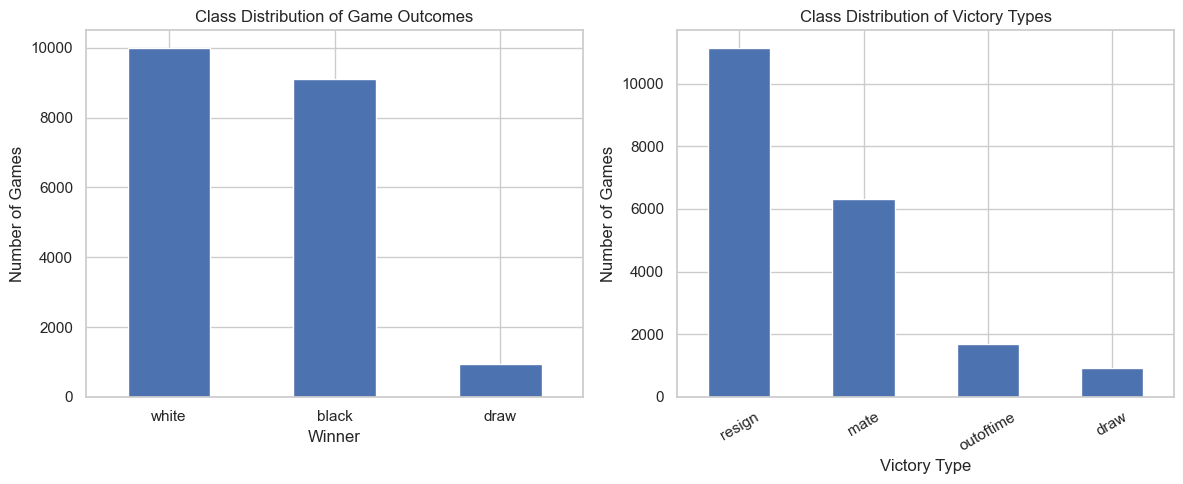

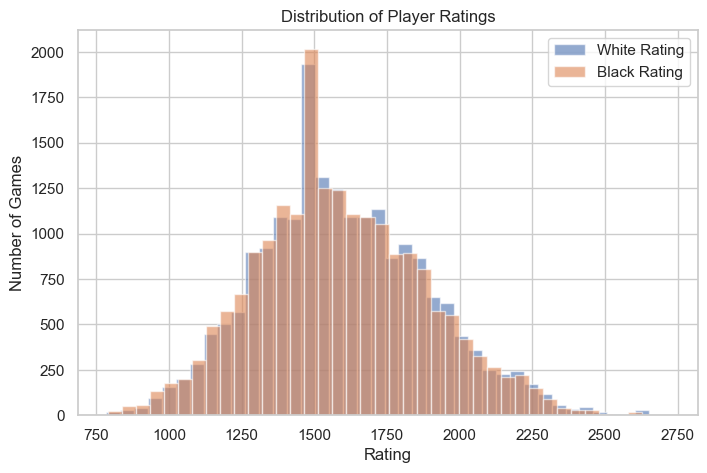

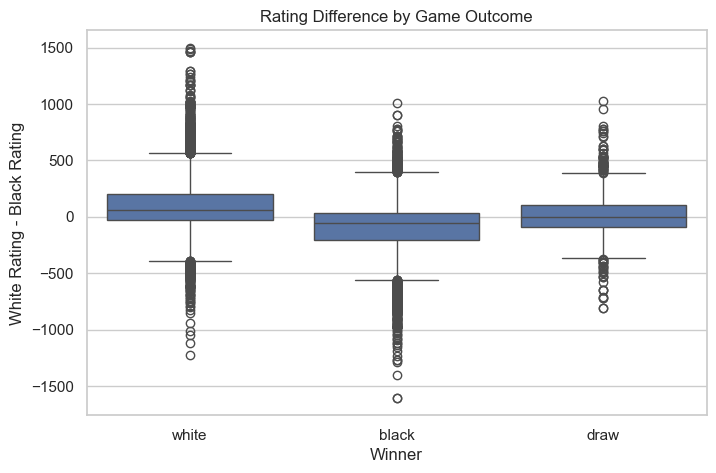

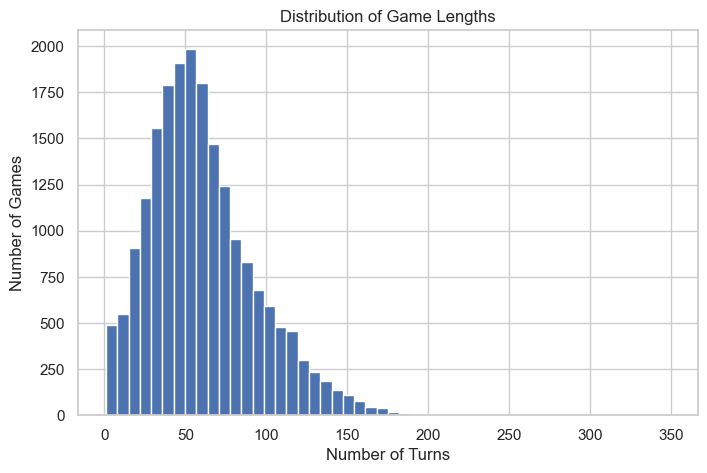

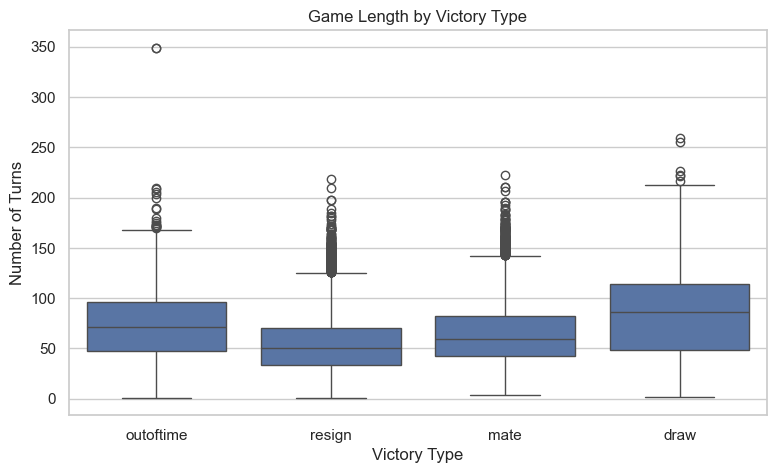

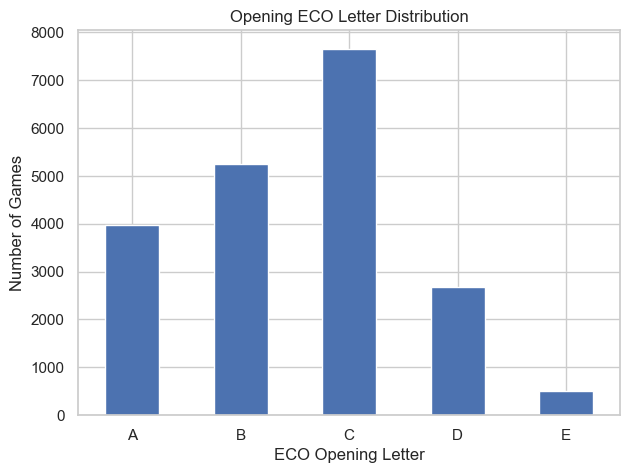

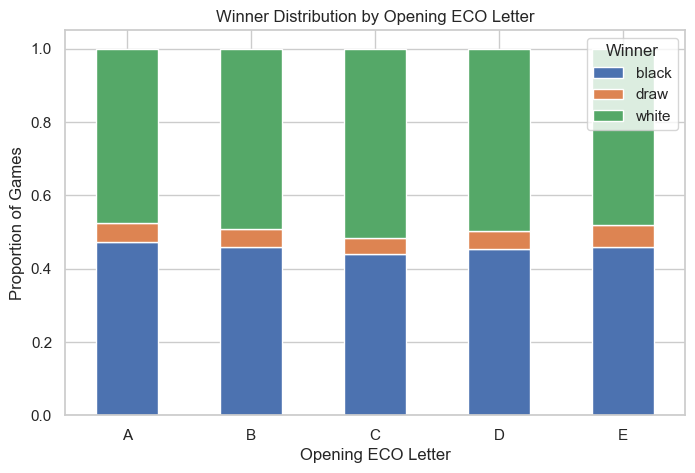

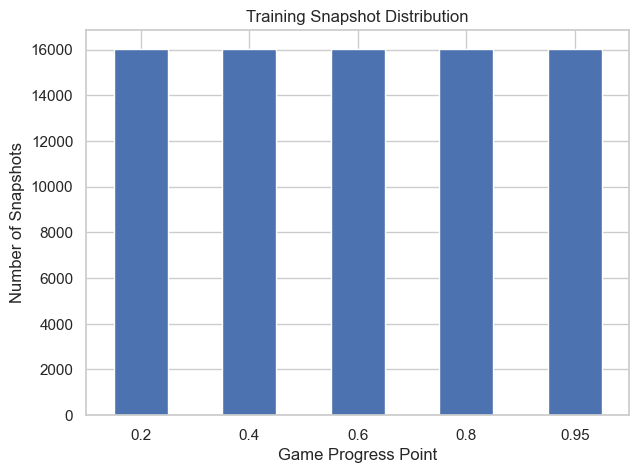

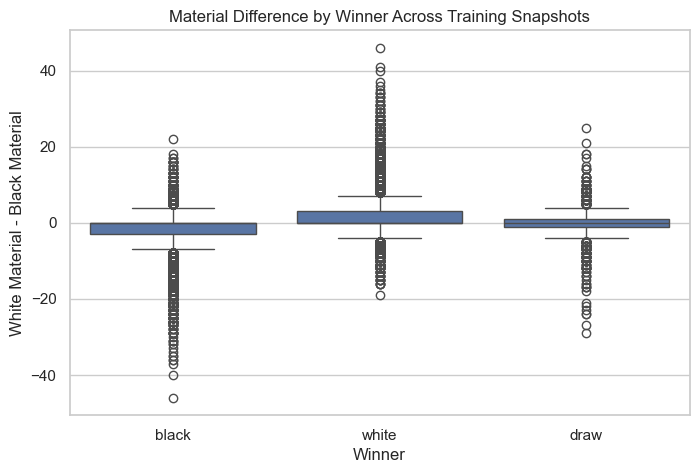

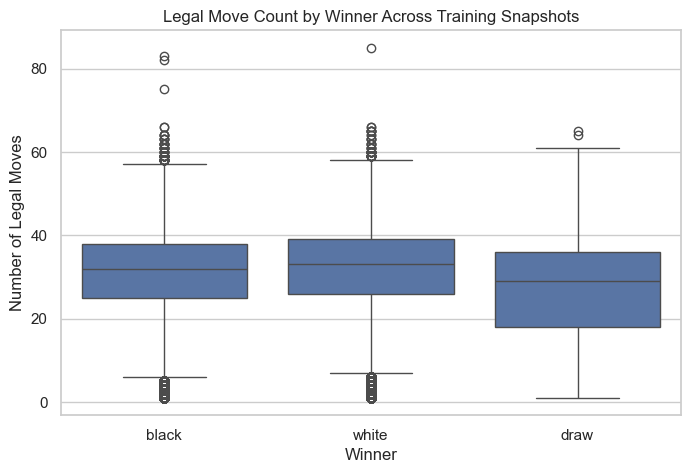

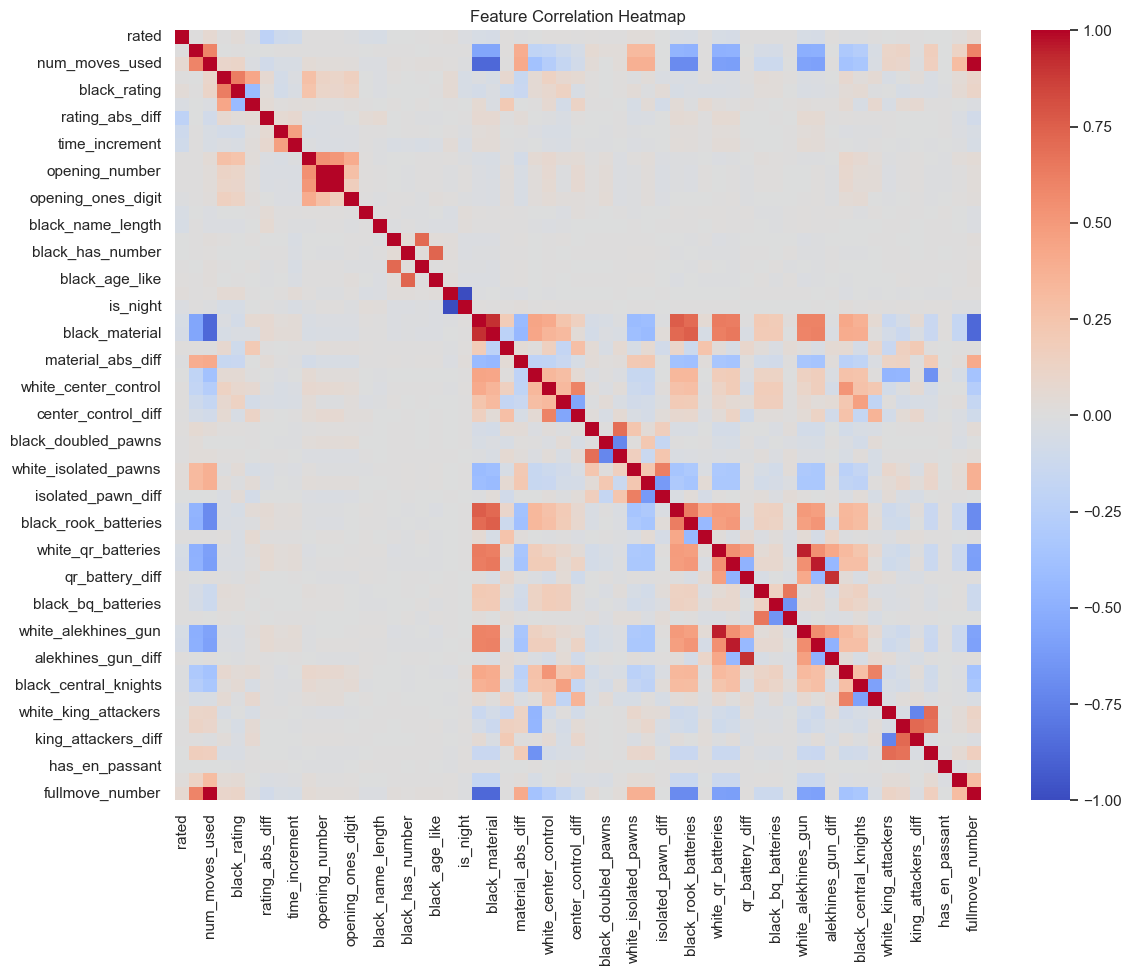

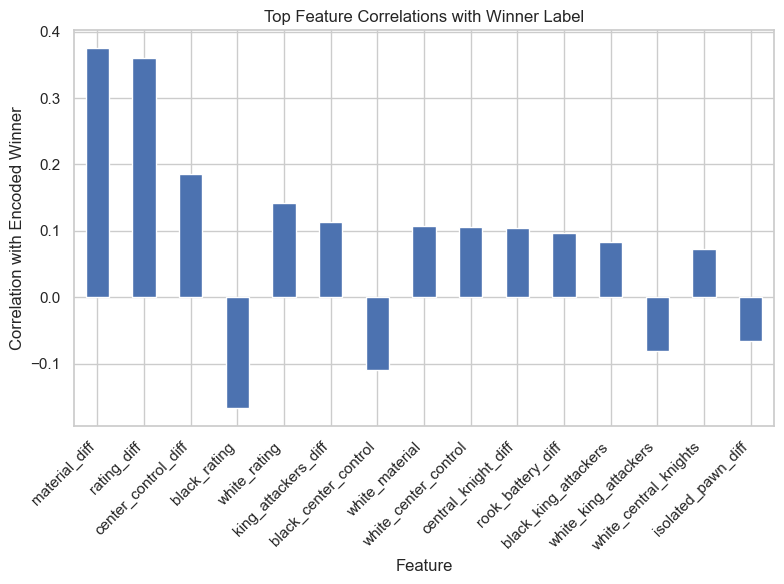

In [4]:
sns.set_theme(style="whitegrid")


# -------------------------------
# 1. Target Class Distributions
# -------------------------------

winner_class_counts = dataset["winner"].value_counts()
victory_status_counts = dataset["victory_status"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

winner_class_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Class Distribution of Game Outcomes")
axes[0].set_xlabel("Winner")
axes[0].set_ylabel("Number of Games")
axes[0].tick_params(axis="x", rotation=0)

victory_status_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Class Distribution of Victory Types")
axes[1].set_xlabel("Victory Type")
axes[1].set_ylabel("Number of Games")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


# -------------------------------
# 2. Rating Distributions
# -------------------------------

plt.figure(figsize=(8, 5))
plt.hist(dataset["white_rating"], bins=40, alpha=0.6, label="White Rating")
plt.hist(dataset["black_rating"], bins=40, alpha=0.6, label="Black Rating")
plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Games")
plt.legend()
plt.show()


# -------------------------------
# 3. Rating Difference vs Winner
# -------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(data=dataset, x="winner", y="rating_diff")
plt.title("Rating Difference by Game Outcome")
plt.xlabel("Winner")
plt.ylabel("White Rating - Black Rating")
plt.show()


# -------------------------------
# 4. Game Length Distribution
# -------------------------------

plt.figure(figsize=(8, 5))
plt.hist(dataset["turns"], bins=50)
plt.title("Distribution of Game Lengths")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Games")
plt.show()


# -------------------------------
# 5. Victory Type vs Game Length
# -------------------------------

plt.figure(figsize=(9, 5))
sns.boxplot(data=dataset, x="victory_status", y="turns")
plt.title("Game Length by Victory Type")
plt.xlabel("Victory Type")
plt.ylabel("Number of Turns")
plt.show()


# -------------------------------
# 6. Opening Strategy Distribution
# -------------------------------

opening_counts = dataset["opening_letter"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
opening_counts.plot(kind="bar")
plt.title("Opening ECO Letter Distribution")
plt.xlabel("ECO Opening Letter")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.show()


# -------------------------------
# 7. Opening Strategy vs Winner
# -------------------------------

opening_winner_table = pd.crosstab(
    dataset["opening_letter"],
    dataset["winner"],
    normalize="index"
)

opening_winner_table.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Winner Distribution by Opening ECO Letter")
plt.xlabel("Opening ECO Letter")
plt.ylabel("Proportion of Games")
plt.xticks(rotation=0)
plt.legend(title="Winner")
plt.show()


# -------------------------------
# 8. Snapshot Progress Distribution
# -------------------------------

plt.figure(figsize=(7, 5))
train_expanded["progress"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Snapshot Distribution")
plt.xlabel("Game Progress Point")
plt.ylabel("Number of Snapshots")
plt.xticks(rotation=0)
plt.show()


# -------------------------------
# 9. Material Difference by Winner
# -------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_expanded, x="winner", y="material_diff")
plt.title("Material Difference by Winner Across Training Snapshots")
plt.xlabel("Winner")
plt.ylabel("White Material - Black Material")
plt.show()


# -------------------------------
# 10. Mobility by Winner
# -------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_expanded, x="winner", y="num_legal_moves")
plt.title("Legal Move Count by Winner Across Training Snapshots")
plt.xlabel("Winner")
plt.ylabel("Number of Legal Moves")
plt.show()


# -------------------------------
# 11. Correlation Heatmap
# -------------------------------

plot_feature_cols = [
    "rated",
    "progress",
    "num_moves_used",
    "white_rating",
    "black_rating",
    "rating_diff",
    "rating_abs_diff",
    "base_time",
    "time_increment",
    "opening_ply",
    "opening_number",
    "opening_tens_digit",
    "opening_ones_digit",
    "white_name_length",
    "black_name_length",
    "white_has_number",
    "black_has_number",
    "white_age_like",
    "black_age_like",
    "is_daytime",
    "is_night",
    "white_material",
    "black_material",
    "material_diff",
    "material_abs_diff",
    "num_legal_moves",
    "white_center_control",
    "black_center_control",
    "center_control_diff",
    "white_doubled_pawns",
    "black_doubled_pawns",
    "doubled_pawn_diff",
    "white_isolated_pawns",
    "black_isolated_pawns",
    "isolated_pawn_diff",
    "white_rook_batteries",
    "black_rook_batteries",
    "rook_battery_diff",
    "white_qr_batteries",
    "black_qr_batteries",
    "qr_battery_diff",
    "white_bq_batteries",
    "black_bq_batteries",
    "bq_battery_diff",
    "white_alekhines_gun",
    "black_alekhines_gun",
    "alekhines_gun_diff",
    "white_central_knights",
    "black_central_knights",
    "central_knight_diff",
    "white_king_attackers",
    "black_king_attackers",
    "king_attackers_diff",
    "side_to_move_in_check",
    "has_en_passant",
    "halfmove_clock",
    "fullmove_number",
]

plot_feature_cols = [col for col in plot_feature_cols if col in train_expanded.columns]

corr_matrix = train_expanded[plot_feature_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


# -------------------------------
# 12. Correlation with Encoded Winner
# -------------------------------

corr_with_winner = train_expanded[plot_feature_cols + ["y_winner"]].corr()["y_winner"]
corr_with_winner = corr_with_winner.drop("y_winner").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
corr_with_winner.head(15).plot(kind="bar")
plt.title("Top Feature Correlations with Winner Label")
plt.xlabel("Feature")
plt.ylabel("Correlation with Encoded Winner")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
x_train = X_train_global
x_test = X_test_global

y_train_winner = y_winner_train
y_test_winner = y_winner_test

y_train_status = y_status_train
y_test_status = y_status_test

y_train_multi = train_expanded[["winner", "victory_status"]]
y_test_multi = test_expanded[["winner", "victory_status"]]

groups = train_expanded["id"]

print("Random Forest training shape:", x_train.shape)
print("Random Forest testing shape:", x_test.shape)


param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

group_cv = GroupKFold(n_splits=5)
candidate_feature_counts = [10, 15, 20, 25, 30, 40, 50, 75, 99]


def get_feature_importance_ranking(x_train, y_train, feature_cols):
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(x_train, y_train)

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    return importance_df


def find_best_feature_set_single_output(
    x_train,
    y_train,
    feature_cols,
    groups,
    model_name,
    candidate_feature_counts
):
    print("\n" + "=" * 70)
    print(f"Finding best feature set for {model_name}")
    print("=" * 70)

    importance_df = get_feature_importance_ranking(
        x_train,
        y_train,
        feature_cols
    )

    results = []

    for k in candidate_feature_counts:
        k = min(k, len(feature_cols))
        selected_features = importance_df.head(k)["feature"].tolist()

        rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        scores = cross_val_score(
            rf,
            x_train[selected_features],
            y_train,
            cv=group_cv,
            groups=groups,
            scoring="f1_weighted",
            n_jobs=-1
        )

        results.append({
            "num_features": k,
            "mean_f1": scores.mean(),
            "std_f1": scores.std(),
            "features": selected_features
        })

        print(f"Top {k:3d} features | F1 = {scores.mean():.4f} ± {scores.std():.4f}")

    results_df = pd.DataFrame(results)
    best_row = results_df.sort_values("mean_f1", ascending=False).iloc[0]

    best_features = best_row["features"]

    print("\nBest number of features:", best_row["num_features"])
    print("Best CV F1:", best_row["mean_f1"])

    return best_features, importance_df, results_df


def multioutput_f1_score(y_true, y_pred):
    y_true = np.asarray(y_true)

    winner_f1 = f1_score(
        y_true[:, 0],
        y_pred[:, 0],
        average="weighted",
        zero_division=0
    )

    status_f1 = f1_score(
        y_true[:, 1],
        y_pred[:, 1],
        average="weighted",
        zero_division=0
    )

    return (winner_f1 + status_f1) / 2


multioutput_scorer = make_scorer(multioutput_f1_score)


def find_best_feature_set_multi_output(
    x_train,
    y_train_multi,
    feature_cols,
    groups,
    model_name,
    candidate_feature_counts
):
    print("\n" + "=" * 70)
    print(f"Finding best feature set for {model_name}")
    print("=" * 70)

    # Rank features using winner + status importances averaged
    winner_importance = get_feature_importance_ranking(
        x_train,
        y_train_multi["winner"],
        feature_cols
    )

    status_importance = get_feature_importance_ranking(
        x_train,
        y_train_multi["victory_status"],
        feature_cols
    )

    merged_importance = winner_importance.merge(
        status_importance,
        on="feature",
        suffixes=("_winner", "_status")
    )

    merged_importance["importance"] = (
        merged_importance["importance_winner"] +
        merged_importance["importance_status"]
    ) / 2

    importance_df = merged_importance.sort_values("importance", ascending=False)

    results = []

    for k in candidate_feature_counts:
        k = min(k, len(feature_cols))
        selected_features = importance_df.head(k)["feature"].tolist()

        base_rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        multi_rf = MultiOutputClassifier(base_rf, n_jobs=-1)

        scores = cross_val_score(
            multi_rf,
            x_train[selected_features],
            y_train_multi,
            cv=group_cv,
            groups=groups,
            scoring=multioutput_scorer,
            n_jobs=-1
        )

        results.append({
            "num_features": k,
            "mean_f1": scores.mean(),
            "std_f1": scores.std(),
            "features": selected_features
        })

        print(f"Top {k:3d} features | Avg Multi-Output F1 = {scores.mean():.4f} ± {scores.std():.4f}")

    results_df = pd.DataFrame(results)
    best_row = results_df.sort_values("mean_f1", ascending=False).iloc[0]

    best_features = best_row["features"]

    print("\nBest number of features:", best_row["num_features"])
    print("Best CV Avg F1:", best_row["mean_f1"])

    return best_features, importance_df, results_df


Random Forest training shape: (80230, 99)
Random Forest testing shape: (20060, 99)


In [6]:
winner_best_features, winner_importance_df, winner_feature_results = \
    find_best_feature_set_single_output(
        x_train=x_train,
        y_train=y_train_winner,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Winner RF",
        candidate_feature_counts=candidate_feature_counts
    )

status_best_features, status_importance_df, status_feature_results = \
    find_best_feature_set_single_output(
        x_train=x_train,
        y_train=y_train_status,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Victory Status RF",
        candidate_feature_counts=candidate_feature_counts
    )

multi_best_features, multi_importance_df, multi_feature_results = \
    find_best_feature_set_multi_output(
        x_train=x_train,
        y_train_multi=y_train_multi,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Multi-Output RF",
        candidate_feature_counts=candidate_feature_counts
    )


Finding best feature set for Winner RF
Top  10 features | F1 = 0.6642 ± 0.0075
Top  15 features | F1 = 0.6681 ± 0.0072
Top  20 features | F1 = 0.6699 ± 0.0062
Top  25 features | F1 = 0.6716 ± 0.0052
Top  30 features | F1 = 0.6726 ± 0.0067
Top  40 features | F1 = 0.6738 ± 0.0058
Top  50 features | F1 = 0.6734 ± 0.0074
Top  75 features | F1 = 0.6757 ± 0.0075
Top  99 features | F1 = 0.6777 ± 0.0077

Best number of features: 99
Best CV F1: 0.6777108569789064

Finding best feature set for Victory Status RF
Top  10 features | F1 = 0.4986 ± 0.0089
Top  15 features | F1 = 0.5149 ± 0.0072
Top  20 features | F1 = 0.5162 ± 0.0077
Top  25 features | F1 = 0.5154 ± 0.0079
Top  30 features | F1 = 0.5143 ± 0.0086
Top  40 features | F1 = 0.5108 ± 0.0074
Top  50 features | F1 = 0.5092 ± 0.0079
Top  75 features | F1 = 0.5071 ± 0.0088
Top  99 features | F1 = 0.5049 ± 0.0061

Best number of features: 20
Best CV F1: 0.5162122054560196

Finding best feature set for Multi-Output RF
Top  10 features | Avg Mul

In [7]:
rf_winner_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_status_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

multi_rf_base = MultiOutputClassifier(
    RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    n_jobs=-1
)

winner_search = RandomizedSearchCV(
    estimator=rf_winner_base,
    param_distributions=param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

status_search = RandomizedSearchCV(
    estimator=rf_status_base,
    param_distributions=param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

multi_param_distributions = {
    "estimator__n_estimators": [100, 200, 300, 400],
    "estimator__max_depth": [None, 10, 20, 30, 40],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["sqrt", "log2", None]
}

multi_search = RandomizedSearchCV(
    estimator=multi_rf_base,
    param_distributions=multi_param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring=multioutput_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Optimizing winner model...")
winner_search.fit(x_train[winner_best_features], y_train_winner, groups=groups)

print("\nOptimizing victory status model...")
status_search.fit(x_train[status_best_features], y_train_status, groups=groups)

print("\nOptimizing multi-output model...")
multi_search.fit(x_train[multi_best_features], y_train_multi, groups=groups)

rf_winner_best = winner_search.best_estimator_
rf_status_best = status_search.best_estimator_
rf_multi_best = multi_search.best_estimator_

print("\nBest winner parameters:")
print(winner_search.best_params_)
print("Best winner CV weighted F1:", winner_search.best_score_)

print("\nBest status parameters:")
print(status_search.best_params_)
print("Best status CV weighted F1:", status_search.best_score_)

print("\nBest multi-output parameters:")
print(multi_search.best_params_)
print("Best multi-output CV average F1:", multi_search.best_score_)

Optimizing winner model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Optimizing victory status model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Optimizing multi-output model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best winner parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
Best winner CV weighted F1: 0.6828954968736776

Best status parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
Best status CV weighted F1: 0.5435080456708757

Best multi-output parameters:
{'estimator__n_estimators': 400, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 2, 'estimator__max_features': 'log2', 'estimator__max_depth': 30}
Best multi-output CV average F1: 0.6109170308447899



--- Selected Feature Winner RF ---
Accuracy: 0.7167497507477567
Precision weighted: 0.7117050113733239
Recall weighted: 0.7167497507477567
F1 weighted: 0.7102570799587992

Classification Report:
              precision    recall  f1-score   support

       black       0.71      0.72      0.72      9110
        draw       0.55      0.20      0.30       950
       white       0.73      0.76      0.74     10000

    accuracy                           0.72     20060
   macro avg       0.66      0.56      0.59     20060
weighted avg       0.71      0.72      0.71     20060



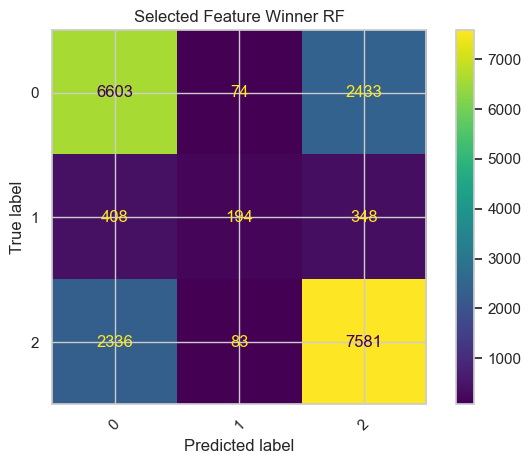


--- Selected Feature Status RF ---
Accuracy: 0.6029411764705882
Precision weighted: 0.5840407205576161
Recall weighted: 0.6029411764705882
F1 weighted: 0.5799117567606364

Classification Report:
              precision    recall  f1-score   support

        draw       0.43      0.20      0.28       900
        mate       0.55      0.44      0.49      6475
   outoftime       0.46      0.20      0.28      1760
      resign       0.64      0.80      0.71     10925

    accuracy                           0.60     20060
   macro avg       0.52      0.41      0.44     20060
weighted avg       0.58      0.60      0.58     20060



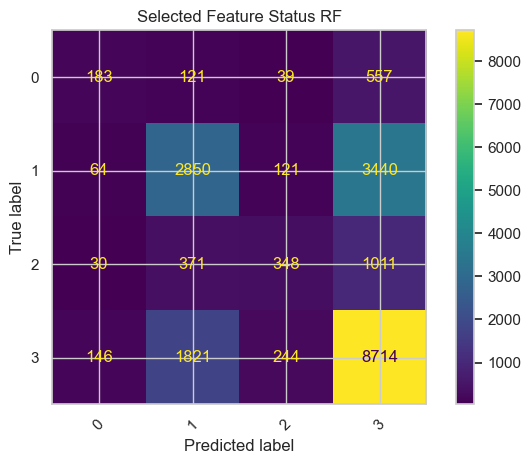


--- Selected Feature Multi-Output RF - Winner ---
Accuracy: 0.7142572283150548
Precision weighted: 0.7094292737373724
Recall weighted: 0.7142572283150548
F1 weighted: 0.7073593250041156

Classification Report:
              precision    recall  f1-score   support

       black       0.70      0.72      0.71      9110
        draw       0.56      0.19      0.29       950
       white       0.73      0.76      0.74     10000

    accuracy                           0.71     20060
   macro avg       0.67      0.56      0.58     20060
weighted avg       0.71      0.71      0.71     20060



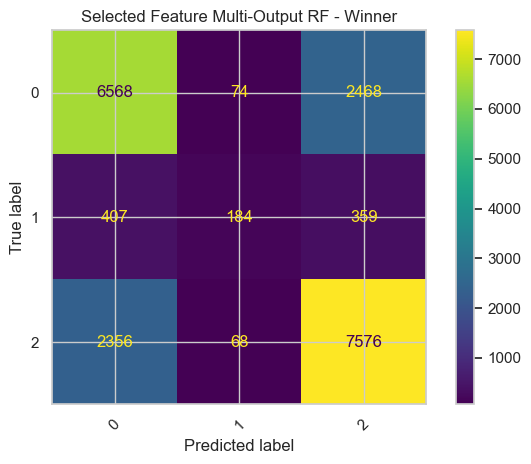


--- Selected Feature Multi-Output RF - Status ---
Accuracy: 0.6029411764705882
Precision weighted: 0.5856852339129474
Recall weighted: 0.6029411764705882
F1 weighted: 0.5801508006919577

Classification Report:
              precision    recall  f1-score   support

        draw       0.47      0.22      0.30       900
        mate       0.55      0.44      0.49      6475
   outoftime       0.48      0.19      0.28      1760
      resign       0.63      0.80      0.71     10925

    accuracy                           0.60     20060
   macro avg       0.53      0.41      0.44     20060
weighted avg       0.59      0.60      0.58     20060



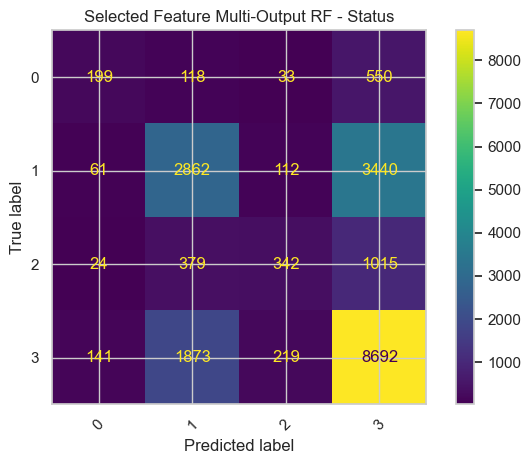


Random Forest Validation at 20% Game Progress

--- Winner RF ---
Accuracy: 0.6587736789631107
Precision weighted: 0.6729589476088964
Recall weighted: 0.6587736789631107
F1 weighted: 0.6480252245708114

Classification Report:
              precision    recall  f1-score   support

       black       0.65      0.64      0.64      1822
        draw       1.00      0.11      0.20       190
       white       0.66      0.73      0.69      2000

    accuracy                           0.66      4012
   macro avg       0.77      0.49      0.51      4012
weighted avg       0.67      0.66      0.65      4012



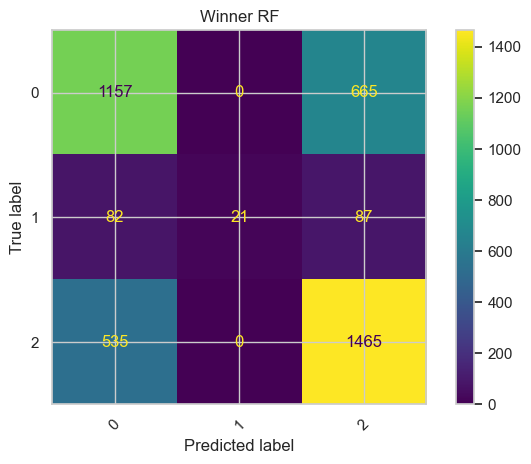


--- Status RF ---
Accuracy: 0.5962113659022931
Precision weighted: 0.6156593192274583
Recall weighted: 0.5962113659022931
F1 weighted: 0.5350122202766027

Classification Report:
              precision    recall  f1-score   support

        draw       0.76      0.11      0.19       180
        mate       0.59      0.26      0.36      1295
   outoftime       0.78      0.13      0.22       352
      resign       0.59      0.91      0.72      2185

    accuracy                           0.60      4012
   macro avg       0.68      0.35      0.37      4012
weighted avg       0.62      0.60      0.54      4012



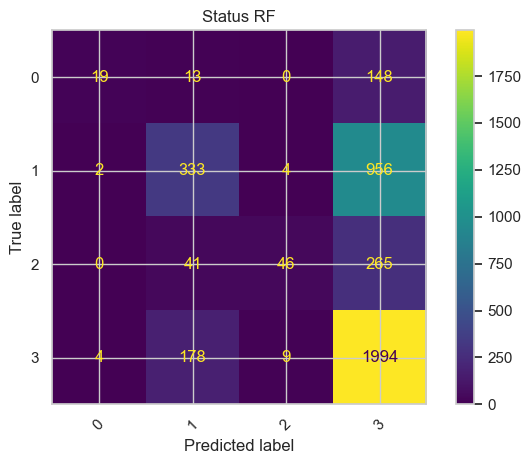


--- Multi-Output RF Winner ---
Accuracy: 0.6502991026919243
Precision weighted: 0.6648203955249571
Recall weighted: 0.6502991026919243
F1 weighted: 0.6397100789370448

Classification Report:
              precision    recall  f1-score   support

       black       0.64      0.63      0.63      1822
        draw       1.00      0.11      0.20       190
       white       0.65      0.72      0.69      2000

    accuracy                           0.65      4012
   macro avg       0.77      0.49      0.51      4012
weighted avg       0.66      0.65      0.64      4012



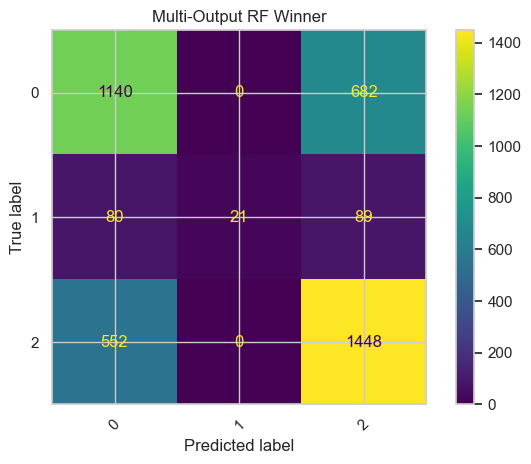


--- Multi-Output RF Status ---
Accuracy: 0.597457627118644
Precision weighted: 0.6288284938116228
Recall weighted: 0.597457627118644
F1 weighted: 0.5330035455489357

Classification Report:
              precision    recall  f1-score   support

        draw       0.90      0.11      0.19       180
        mate       0.60      0.24      0.35      1295
   outoftime       0.82      0.13      0.23       352
      resign       0.59      0.92      0.72      2185

    accuracy                           0.60      4012
   macro avg       0.73      0.35      0.37      4012
weighted avg       0.63      0.60      0.53      4012



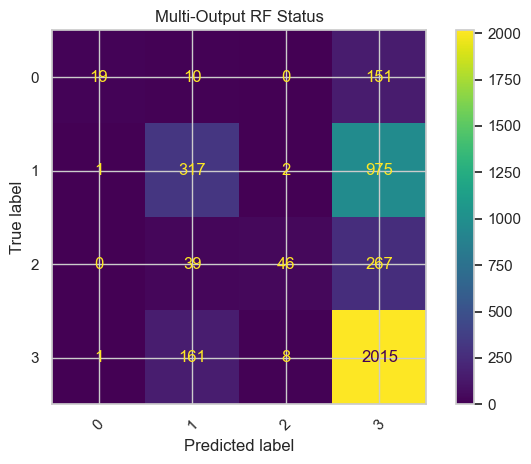


Random Forest Validation at 40% Game Progress

--- Winner RF ---
Accuracy: 0.67098703888335
Precision weighted: 0.6811872815429377
Recall weighted: 0.67098703888335
F1 weighted: 0.6610814544946617

Classification Report:
              precision    recall  f1-score   support

       black       0.65      0.68      0.66      1822
        draw       0.92      0.12      0.21       190
       white       0.69      0.72      0.70      2000

    accuracy                           0.67      4012
   macro avg       0.75      0.50      0.52      4012
weighted avg       0.68      0.67      0.66      4012



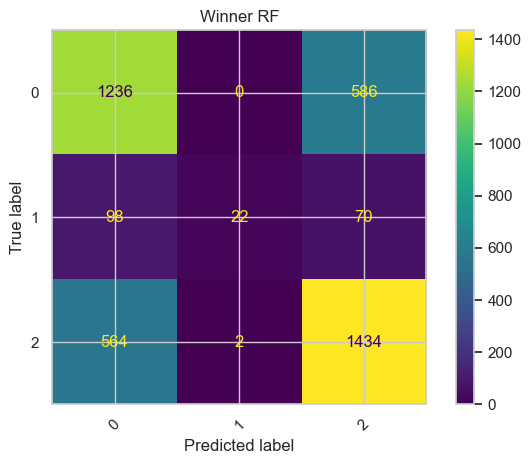


--- Status RF ---
Accuracy: 0.6011964107676969
Precision weighted: 0.607832050383586
Recall weighted: 0.6011964107676969
F1 weighted: 0.5570892459061195

Classification Report:
              precision    recall  f1-score   support

        draw       0.70      0.11      0.18       180
        mate       0.56      0.35      0.43      1295
   outoftime       0.74      0.14      0.24       352
      resign       0.61      0.87      0.71      2185

    accuracy                           0.60      4012
   macro avg       0.65      0.37      0.39      4012
weighted avg       0.61      0.60      0.56      4012



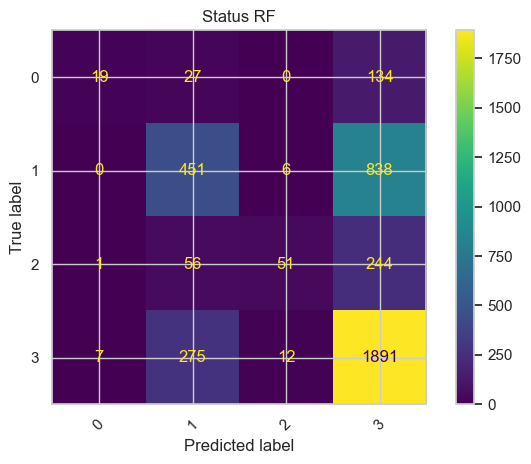


--- Multi-Output RF Winner ---
Accuracy: 0.6754735792622134
Precision weighted: 0.6854612407482334
Recall weighted: 0.6754735792622134
F1 weighted: 0.665458016353598

Classification Report:
              precision    recall  f1-score   support

       black       0.66      0.68      0.67      1822
        draw       0.92      0.12      0.21       190
       white       0.69      0.72      0.71      2000

    accuracy                           0.68      4012
   macro avg       0.75      0.51      0.53      4012
weighted avg       0.69      0.68      0.67      4012



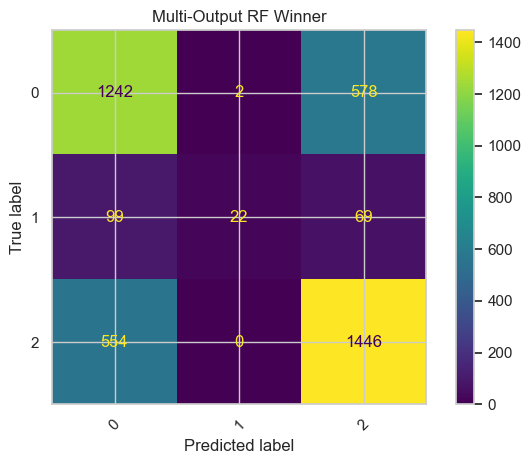


--- Multi-Output RF Status ---
Accuracy: 0.6004486540378864
Precision weighted: 0.613870791172252
Recall weighted: 0.6004486540378864
F1 weighted: 0.5557758749635499

Classification Report:
              precision    recall  f1-score   support

        draw       0.83      0.11      0.20       180
        mate       0.55      0.35      0.43      1295
   outoftime       0.77      0.14      0.24       352
      resign       0.61      0.87      0.71      2185

    accuracy                           0.60      4012
   macro avg       0.69      0.37      0.39      4012
weighted avg       0.61      0.60      0.56      4012



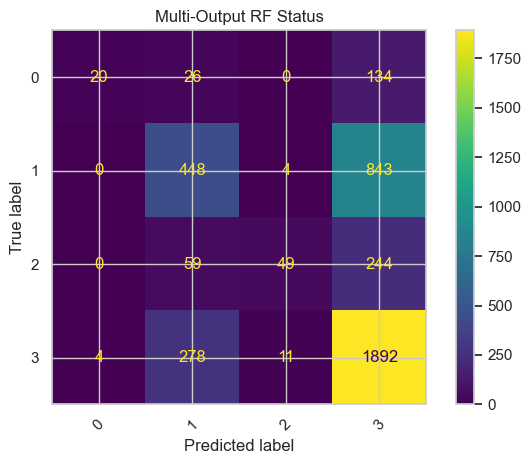


Random Forest Validation at 60% Game Progress

--- Winner RF ---
Accuracy: 0.7190927218344965
Precision weighted: 0.7155095307738442
Recall weighted: 0.7190927218344965
F1 weighted: 0.7110458662195674

Classification Report:
              precision    recall  f1-score   support

       black       0.70      0.73      0.72      1822
        draw       0.62      0.17      0.26       190
       white       0.74      0.76      0.75      2000

    accuracy                           0.72      4012
   macro avg       0.68      0.55      0.58      4012
weighted avg       0.72      0.72      0.71      4012



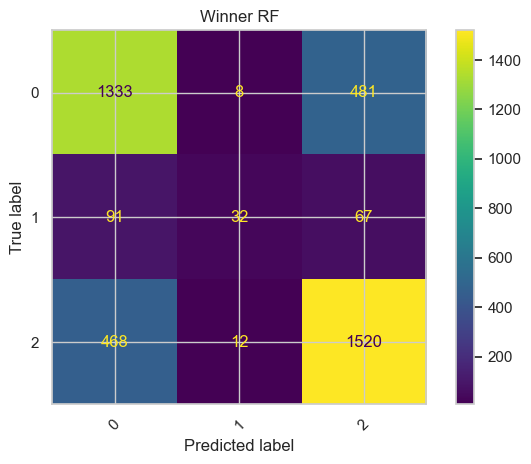


--- Status RF ---
Accuracy: 0.6051844466600199
Precision weighted: 0.5834833527913187
Recall weighted: 0.6051844466600199
F1 weighted: 0.5763152000270986

Classification Report:
              precision    recall  f1-score   support

        draw       0.42      0.15      0.22       180
        mate       0.55      0.42      0.48      1295
   outoftime       0.47      0.18      0.26       352
      resign       0.63      0.82      0.72      2185

    accuracy                           0.61      4012
   macro avg       0.52      0.39      0.42      4012
weighted avg       0.58      0.61      0.58      4012



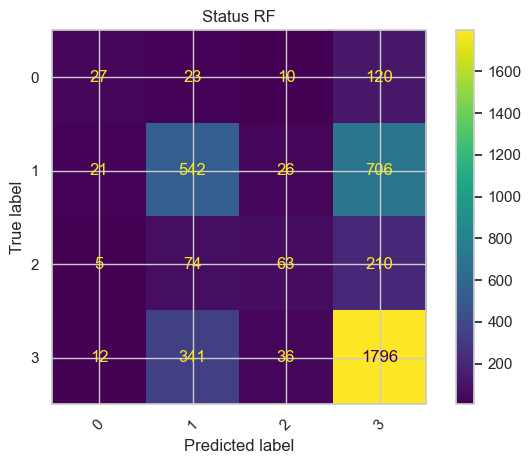


--- Multi-Output RF Winner ---
Accuracy: 0.7161016949152542
Precision weighted: 0.7112316481255158
Recall weighted: 0.7161016949152542
F1 weighted: 0.7077889254442157

Classification Report:
              precision    recall  f1-score   support

       black       0.70      0.73      0.71      1822
        draw       0.58      0.16      0.25       190
       white       0.73      0.76      0.75      2000

    accuracy                           0.72      4012
   macro avg       0.67      0.55      0.57      4012
weighted avg       0.71      0.72      0.71      4012



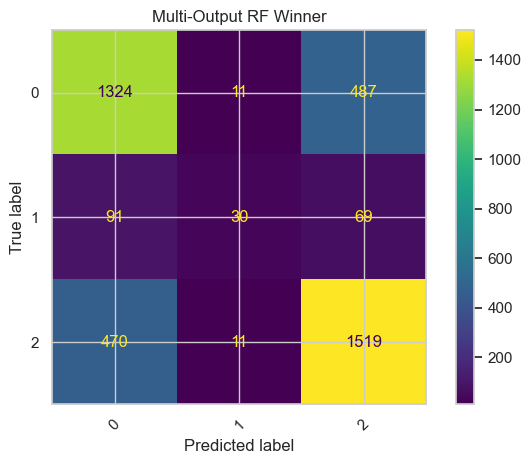


--- Multi-Output RF Status ---
Accuracy: 0.6044366899302094
Precision weighted: 0.5851029486666628
Recall weighted: 0.6044366899302094
F1 weighted: 0.5775396883484998

Classification Report:
              precision    recall  f1-score   support

        draw       0.44      0.16      0.24       180
        mate       0.54      0.43      0.48      1295
   outoftime       0.50      0.19      0.27       352
      resign       0.64      0.81      0.71      2185

    accuracy                           0.60      4012
   macro avg       0.53      0.40      0.43      4012
weighted avg       0.59      0.60      0.58      4012



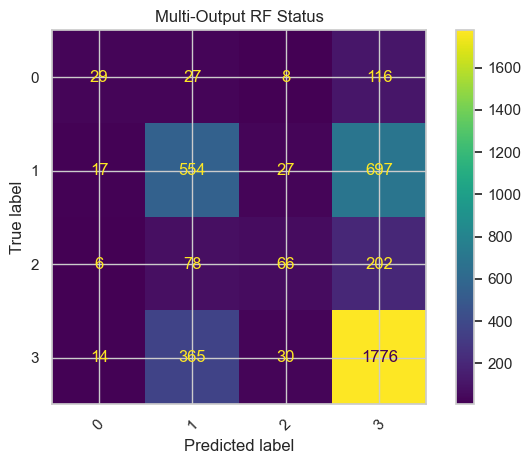


Random Forest Validation at 80% Game Progress

--- Winner RF ---
Accuracy: 0.7452642073778664
Precision weighted: 0.7400440217133795
Recall weighted: 0.7452642073778664
F1 weighted: 0.7416356269848816

Classification Report:
              precision    recall  f1-score   support

       black       0.74      0.77      0.75      1822
        draw       0.43      0.27      0.34       190
       white       0.77      0.77      0.77      2000

    accuracy                           0.75      4012
   macro avg       0.65      0.60      0.62      4012
weighted avg       0.74      0.75      0.74      4012



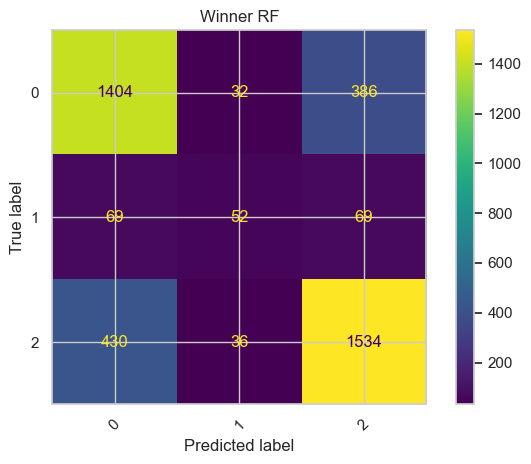


--- Status RF ---
Accuracy: 0.6096709870388833
Precision weighted: 0.5978184852147623
Recall weighted: 0.6096709870388833
F1 weighted: 0.6017466588765522

Classification Report:
              precision    recall  f1-score   support

        draw       0.38      0.30      0.33       180
        mate       0.55      0.53      0.54      1295
   outoftime       0.40      0.28      0.33       352
      resign       0.67      0.74      0.70      2185

    accuracy                           0.61      4012
   macro avg       0.50      0.46      0.48      4012
weighted avg       0.60      0.61      0.60      4012



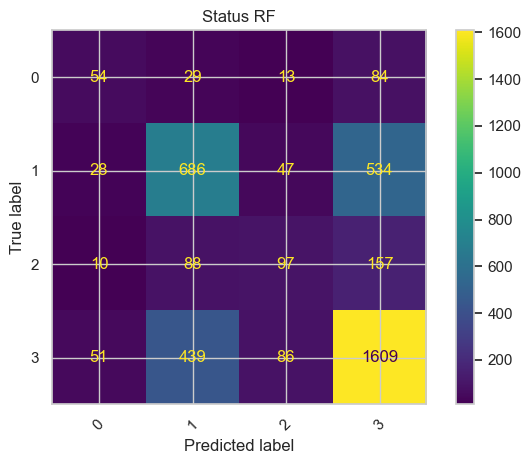


--- Multi-Output RF Winner ---
Accuracy: 0.7427716849451645
Precision weighted: 0.7358621903331235
Recall weighted: 0.7427716849451645
F1 weighted: 0.7376604405396691

Classification Report:
              precision    recall  f1-score   support

       black       0.73      0.77      0.75      1822
        draw       0.43      0.23      0.30       190
       white       0.77      0.77      0.77      2000

    accuracy                           0.74      4012
   macro avg       0.64      0.59      0.60      4012
weighted avg       0.74      0.74      0.74      4012



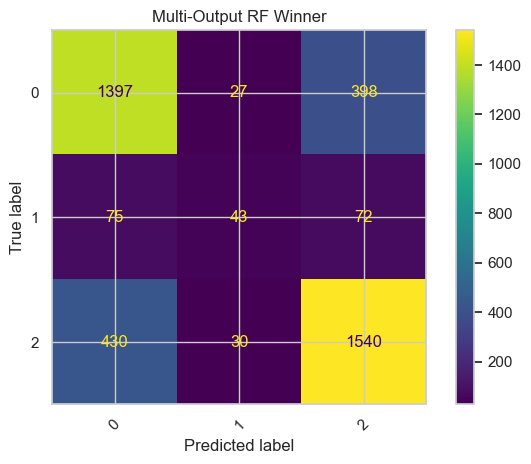


--- Multi-Output RF Status ---
Accuracy: 0.6064307078763709
Precision weighted: 0.5946431325821615
Recall weighted: 0.6064307078763709
F1 weighted: 0.5980270815653879

Classification Report:
              precision    recall  f1-score   support

        draw       0.37      0.31      0.34       180
        mate       0.55      0.54      0.54      1295
   outoftime       0.41      0.25      0.31       352
      resign       0.67      0.73      0.70      2185

    accuracy                           0.61      4012
   macro avg       0.50      0.46      0.47      4012
weighted avg       0.59      0.61      0.60      4012



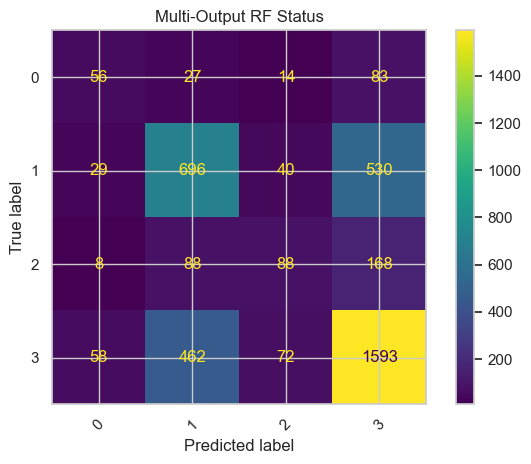


Random Forest Validation at 95% Game Progress

--- Winner RF ---
Accuracy: 0.7896311066799602
Precision weighted: 0.7856894348475456
Recall weighted: 0.7896311066799602
F1 weighted: 0.7869683096538186

Classification Report:
              precision    recall  f1-score   support

       black       0.78      0.81      0.80      1822
        draw       0.50      0.35      0.41       190
       white       0.81      0.81      0.81      2000

    accuracy                           0.79      4012
   macro avg       0.70      0.66      0.67      4012
weighted avg       0.79      0.79      0.79      4012



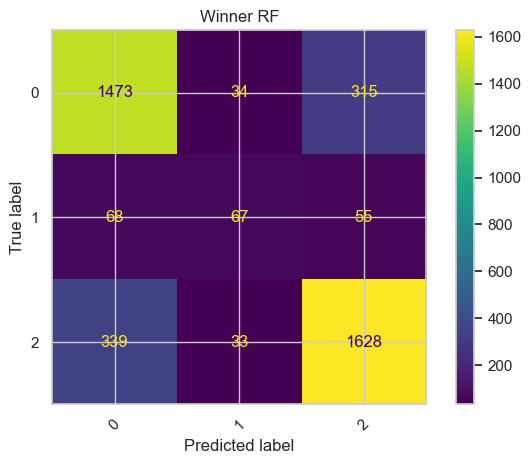


--- Status RF ---
Accuracy: 0.6024426719840479
Precision weighted: 0.6035987773222765
Recall weighted: 0.6024426719840479
F1 weighted: 0.5999319540452082

Classification Report:
              precision    recall  f1-score   support

        draw       0.39      0.36      0.37       180
        mate       0.53      0.65      0.59      1295
   outoftime       0.37      0.26      0.30       352
      resign       0.70      0.65      0.67      2185

    accuracy                           0.60      4012
   macro avg       0.50      0.48      0.48      4012
weighted avg       0.60      0.60      0.60      4012



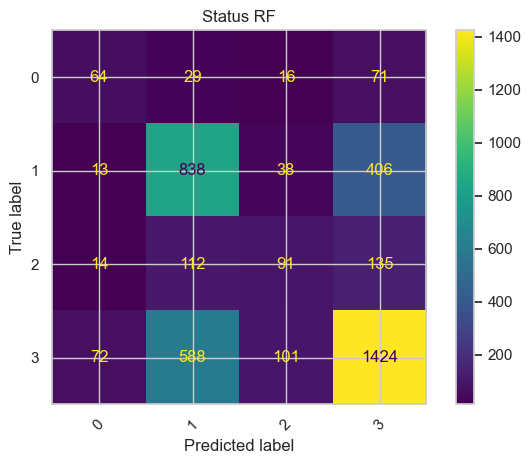


--- Multi-Output RF Winner ---
Accuracy: 0.7866400797607178
Precision weighted: 0.7827450294408383
Recall weighted: 0.7866400797607178
F1 weighted: 0.7838458042810706

Classification Report:
              precision    recall  f1-score   support

       black       0.78      0.80      0.79      1822
        draw       0.53      0.36      0.43       190
       white       0.81      0.81      0.81      2000

    accuracy                           0.79      4012
   macro avg       0.71      0.66      0.68      4012
weighted avg       0.78      0.79      0.78      4012



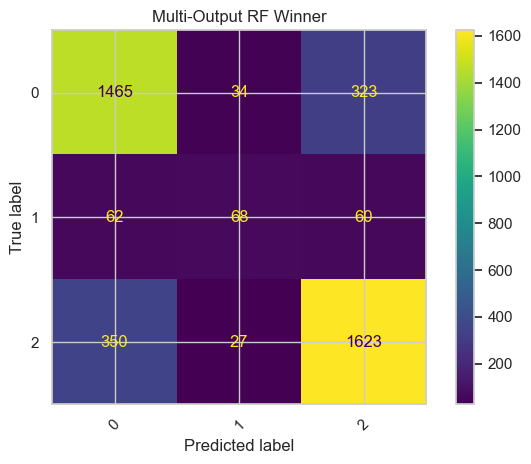


--- Multi-Output RF Status ---
Accuracy: 0.6059322033898306
Precision weighted: 0.6091731528571652
Recall weighted: 0.6059322033898306
F1 weighted: 0.6037874504108968

Classification Report:
              precision    recall  f1-score   support

        draw       0.46      0.42      0.44       180
        mate       0.53      0.65      0.59      1295
   outoftime       0.39      0.26      0.31       352
      resign       0.70      0.65      0.67      2185

    accuracy                           0.61      4012
   macro avg       0.52      0.50      0.50      4012
weighted avg       0.61      0.61      0.60      4012



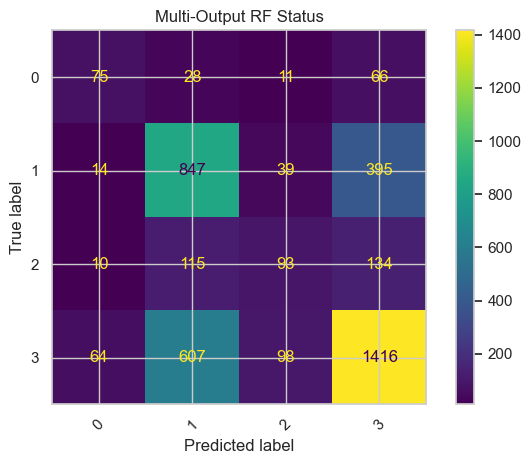

,model,target,progress,progress_percent,f1,recall,precision,accuracy
0,Winner RF,winner,0.20,20.0,0.648025,0.658774,0.672959,0.658774
1,Status RF,status,0.20,20.0,0.535012,0.596211,0.615659,0.596211
2,Multi-Output RF Winner,winner,0.20,20.0,0.639710,0.650299,0.664820,0.650299
3,Multi-Output RF Status,status,0.20,20.0,0.533004,0.597458,0.628828,0.597458
4,Winner RF,winner,0.40,40.0,0.661081,0.670987,0.681187,0.670987
5,Status RF,status,0.40,40.0,0.557089,0.601196,0.607832,0.601196
6,Multi-Output RF Winner,winner,0.40,40.0,0.665458,0.675474,0.685461,0.675474
7,Multi-Output RF Status,status,0.40,40.0,0.555776,0.600449,0.613871,0.600449
8,Winner RF,winner,0.60,60.0,0.711046,0.719093,0.715510,0.719093
9,Status RF,status,0.60,60.0,0.576315,0.605184,0.583483,0.605184


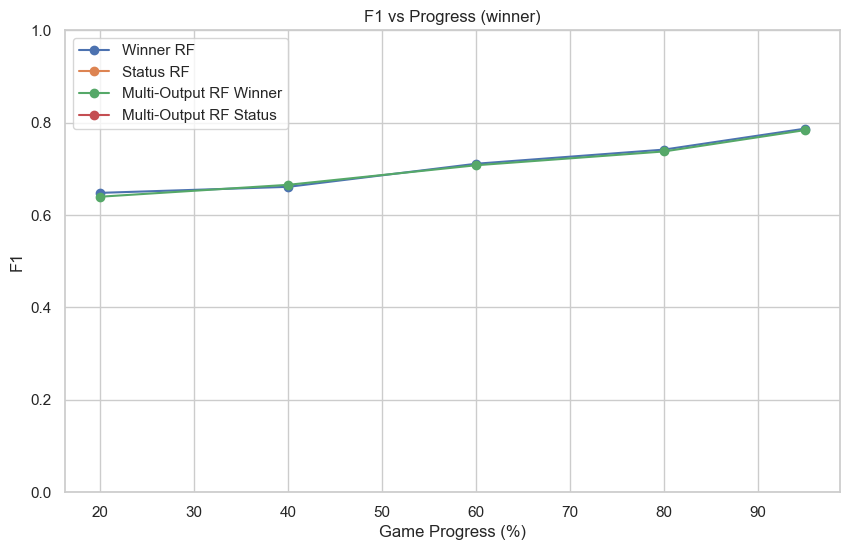

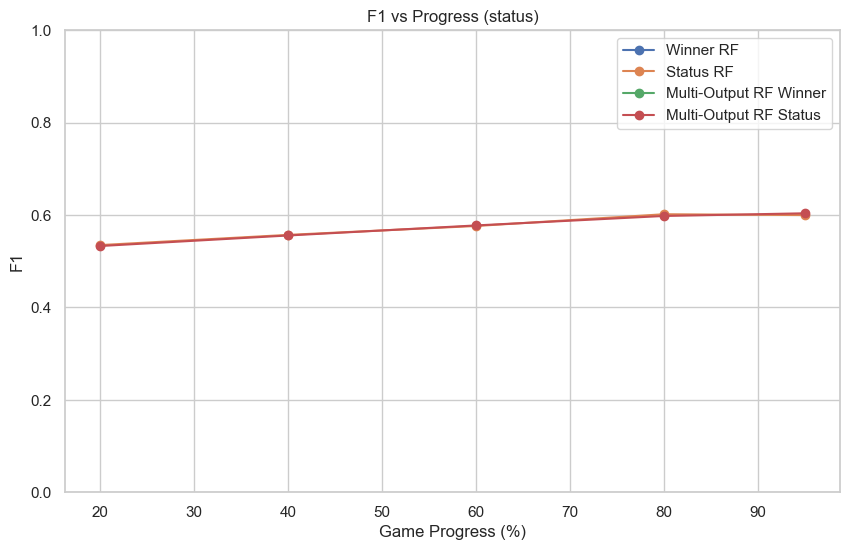

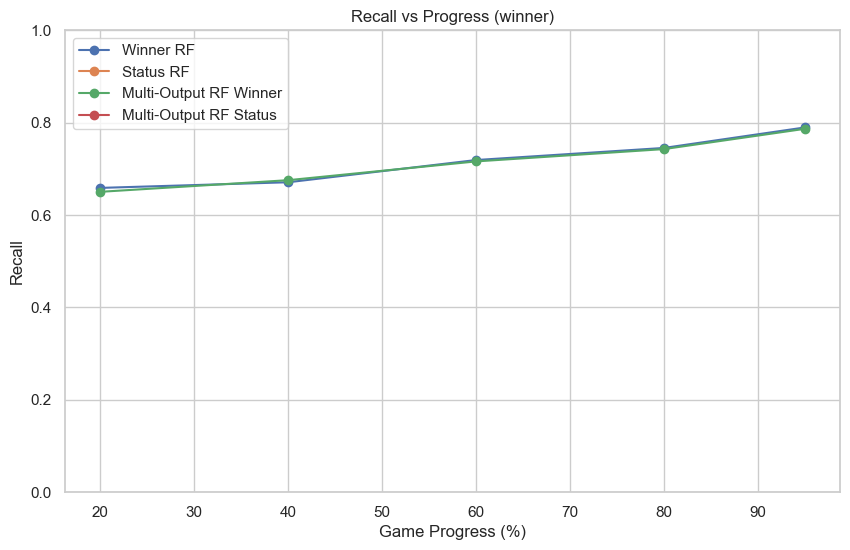

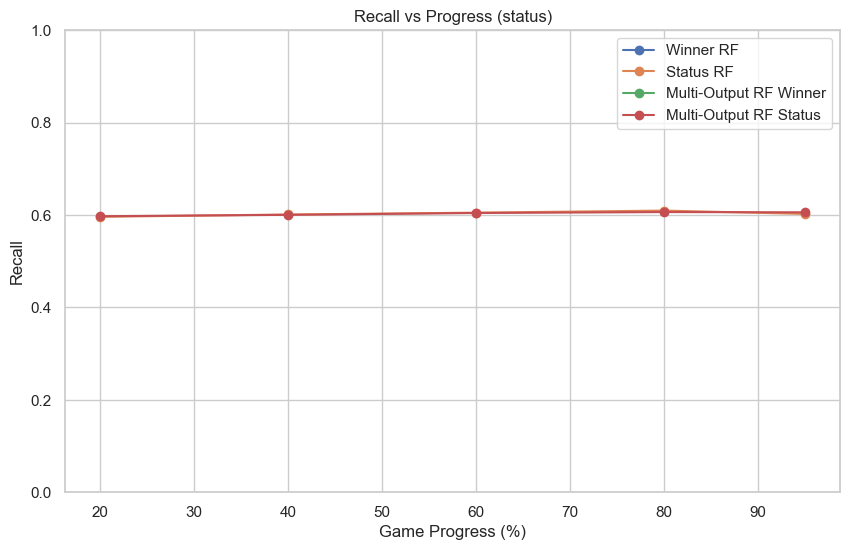

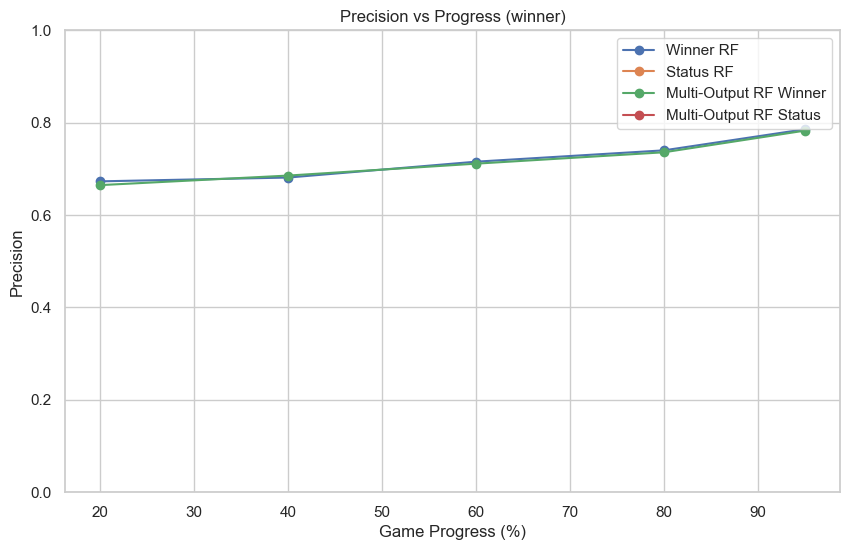

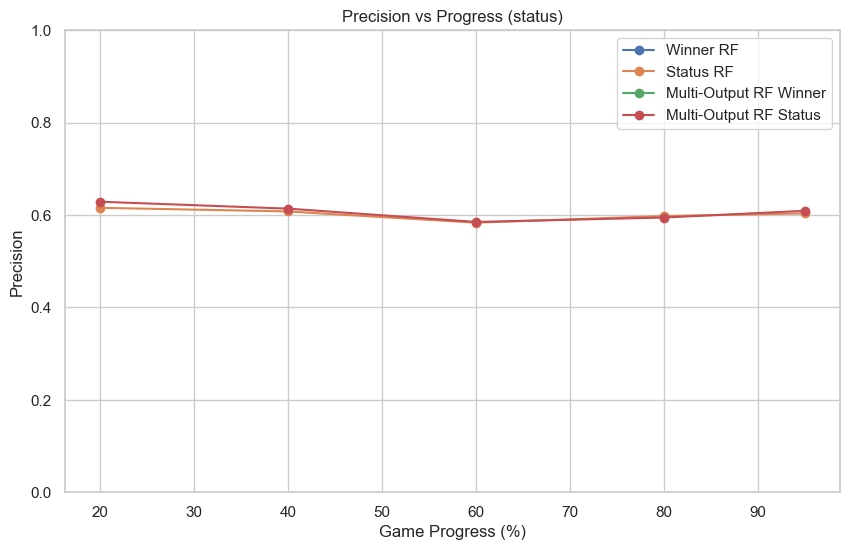

In [9]:
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")

    plt.title(model_name)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_rf_f1_progress(rf_results_df, target, title):
    plot_df = rf_results_df[rf_results_df["target"] == target].copy()

    plt.figure(figsize=(10, 6))

    for model_name in plot_df["model"].unique():
        model_df = plot_df[plot_df["model"] == model_name].sort_values("progress_percent")

        plt.plot(
            model_df["progress_percent"],
            model_df["f1"],
            marker="o",
            label=model_name
        )

    plt.xlabel("Game Progress (%)")
    plt.ylabel("Weighted F1 Score")
    plt.ylim(0, 1)
    plt.xticks([20, 40, 60, 80, 95])
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_metric_progress(results_df, target, metric):
    plt.figure(figsize=(10,6))

    for model_name in results_df["model"].unique():
        df = results_df[
            (results_df["model"] == model_name) &
            (results_df["target"] == target)
        ].sort_values("progress_percent")

        plt.plot(df["progress_percent"], df[metric], marker="o", label=model_name)

    plt.xlabel("Game Progress (%)")
    plt.ylabel(metric.capitalize())
    plt.ylim(0,1)
    plt.legend()
    plt.grid(True)
    plt.title(f"{metric.capitalize()} vs Progress ({target})")
    plt.show()

rf_results = []

def evaluate_predictions(y_true, y_pred, model_name, progress_value=None, target=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n--- {model_name} ---")
    print("Accuracy:", acc)
    print("Precision weighted:", prec)
    print("Recall weighted:", rec)
    print("F1 weighted:", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    plot_conf_matrix(y_true, y_pred, model_name)

    if progress_value is not None and target is not None:
        rf_results.append({
            "model": model_name,
            "target": target,
            "progress": progress_value,
            "progress_percent": progress_value * 100,
            "f1": f1,
            "recall": rec,
            "precision": prec,
            "accuracy": acc
        })



winner_pred = rf_winner_best.predict(x_test[winner_best_features])
status_pred = rf_status_best.predict(x_test[status_best_features])

multi_pred = rf_multi_best.predict(x_test[multi_best_features])
multi_winner_pred = multi_pred[:, 0]
multi_status_pred = multi_pred[:, 1]

evaluate_predictions(
    y_test_winner,
    winner_pred,
    "Selected Feature Winner RF"
)

evaluate_predictions(
    y_test_status,
    status_pred,
    "Selected Feature Status RF"
)

evaluate_predictions(
    y_test_winner,
    multi_winner_pred,
    "Selected Feature Multi-Output RF - Winner"
)

evaluate_predictions(
    y_test_status,
    multi_status_pred,
    "Selected Feature Multi-Output RF - Status"
)

def validate_all_rf_at_progress(progress_value):
    print("\n" + "=" * 70)
    print(f"Random Forest Validation at {int(progress_value * 100)}% Game Progress")
    print("=" * 70)

    progress_mask = np.isclose(test_expanded["progress"], progress_value)

    if progress_mask.sum() == 0:
        print(f"No test samples found for progress = {progress_value}")
        return

    y_winner_progress = test_expanded.loc[progress_mask, "winner"]
    y_status_progress = test_expanded.loc[progress_mask, "victory_status"]

    x_winner_progress = test_expanded.loc[progress_mask, winner_best_features].astype(float)
    x_status_progress = test_expanded.loc[progress_mask, status_best_features].astype(float)
    x_multi_progress = test_expanded.loc[progress_mask, multi_best_features].astype(float)

    winner_pred_progress = rf_winner_best.predict(x_winner_progress)
    status_pred_progress = rf_status_best.predict(x_status_progress)

    multi_pred_progress = rf_multi_best.predict(x_multi_progress)
    multi_winner_pred_progress = multi_pred_progress[:, 0]
    multi_status_pred_progress = multi_pred_progress[:, 1]

    evaluate_predictions(
        y_winner_progress,
        winner_pred_progress,
        f"Winner RF",
        progress_value=progress_value,
        target="winner"
    )

    evaluate_predictions(
        y_status_progress,
        status_pred_progress,
        f"Status RF",
        progress_value=progress_value,
        target="status"
    )

    evaluate_predictions(
        y_winner_progress,
        multi_winner_pred_progress,
        f"Multi-Output RF Winner",
        progress_value=progress_value,
        target="winner"
    )

    evaluate_predictions(
        y_status_progress,
        multi_status_pred_progress,
        f"Multi-Output RF Status",
        progress_value=progress_value,
        target="status"
    )

progress_points_to_test = [0.2, 0.4, 0.6, 0.8, 0.95]

rf_results = []

for p in progress_points_to_test:
    validate_all_rf_at_progress(p)

rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df)

plot_metric_progress(rf_results_df, "winner", "f1")
plot_metric_progress(rf_results_df, "status", "f1")

plot_metric_progress(rf_results_df, "winner", "recall")
plot_metric_progress(rf_results_df, "status", "recall")

plot_metric_progress(rf_results_df, "winner", "precision")
plot_metric_progress(rf_results_df, "status", "precision")

In [10]:
# ------------------------------------------------------------
# 1. SAN Subtokenization
# ------------------------------------------------------------

def san_to_subtokens(san):
    san = str(san).strip()
    san = san.replace("!", "").replace("?", "")

    if san == "O-O":
        return ["castle_kingside"]
    if san == "O-O-O":
        return ["castle_queenside"]

    tokens = []

    suffix_tokens = []
    while len(san) > 0 and san[-1] in ["+", "#"]:
        if san[-1] == "+":
            suffix_tokens.append("check")
        elif san[-1] == "#":
            suffix_tokens.append("mate")
        san = san[:-1]

    promo_match = re.search(r"=([QRBN])", san)
    if promo_match:
        promo_piece = promo_match.group(1)
        san = re.sub(r"=([QRBN])", "", san)
        promo_token = f"promo_{promo_piece}"
    else:
        promo_token = None

    dest_match = re.search(r"([a-h][1-8])$", san)

    if not dest_match:
        return [f"raw_{san}"] + suffix_tokens

    dest = dest_match.group(1)
    san_core = san[:-2]

    if len(san_core) > 0 and san_core[0] in "KQRBN":
        piece = san_core[0]
        san_core = san_core[1:]
    else:
        piece = "P"

    tokens.append(piece)

    if "x" in san_core:
        before_capture, after_capture = san_core.split("x", 1)

        if before_capture:
            for ch in before_capture:
                tokens.append(f"src_{ch}")

        tokens.append("x")

        if after_capture:
            for ch in after_capture:
                tokens.append(f"hint_{ch}")

    else:
        if san_core:
            for ch in san_core:
                tokens.append(f"src_{ch}")

    tokens.append(f"dst_{dest}")

    if promo_token is not None:
        tokens.append(promo_token)

    tokens.extend(reversed(suffix_tokens))

    return tokens


def move_string_to_subtokens(move_string):
    moves = str(move_string).split()
    all_tokens = []

    for move in moves:
        all_tokens.append("<m>")
        all_tokens.extend(san_to_subtokens(move))

    return " ".join(all_tokens)


def build_move_vectors(train_text, test_text, max_tokens=30000):
    train_lengths = pd.Series(train_text).apply(lambda x: len(str(x).split()))

    sequence_length = int(np.percentile(train_lengths, 95))
    sequence_length = max(sequence_length, 20)

    vectorizer = TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=sequence_length,
        standardize=None,
        split="whitespace"
    )

    vectorizer.adapt(train_text)

    X_train = vectorizer(train_text).numpy()
    X_test = vectorizer(test_text).numpy()

    vocab_size = len(vectorizer.get_vocabulary())

    return X_train, X_test, vectorizer, vocab_size, sequence_length

# ------------------------------------------------------------
# Build BOTH move text versions
# ------------------------------------------------------------

# Normal tokenized SAN
train_expanded["moves_normal"] = train_expanded["moves_truncated"].astype(str)
test_expanded["moves_normal"] = test_expanded["moves_truncated"].astype(str)

# Subtokenized SAN
train_expanded["moves_subtok"] = train_expanded["moves_truncated"].apply(move_string_to_subtokens)
test_expanded["moves_subtok"] = test_expanded["moves_truncated"].apply(move_string_to_subtokens)


# ------------------------------------------------------------
# NORMAL SAN vectors
# ------------------------------------------------------------

X_moves_train_normal, X_moves_test_normal, normal_vectorizer, normal_vocab_size, normal_seq_len = build_move_vectors(
    train_expanded["moves_normal"].astype(str).values,
    test_expanded["moves_normal"].astype(str).values
)

# ------------------------------------------------------------
# SUBTOKENIZED SAN vectors
# ------------------------------------------------------------

X_moves_train_subtok, X_moves_test_subtok, subtok_vectorizer, subtok_vocab_size, subtok_seq_len = build_move_vectors(
    train_expanded["moves_subtok"].astype(str).values,
    test_expanded["moves_subtok"].astype(str).values
)


# ------------------------------------------------------------
# 4. Extra Numeric Features
# ------------------------------------------------------------

extra_scaler = StandardScaler()

X_extra_train = extra_scaler.fit_transform(X_train_global).astype(np.float32)
X_extra_test = extra_scaler.transform(X_test_global).astype(np.float32)


# ------------------------------------------------------------
# 5. Labels
# ------------------------------------------------------------

y_winner_train_tf = train_expanded["y_winner"].values
y_winner_test_tf = test_expanded["y_winner"].values

y_status_train_tf = train_expanded["y_status"].values
y_status_test_tf = test_expanded["y_status"].values

n_winner_classes = len(winner_encoder.classes_)
n_status_classes = len(status_encoder.classes_)


print("\nNormal SAN:")
print("Sequence length:", normal_seq_len)
print("Vocabulary size:", normal_vocab_size)
print("X shape:", X_moves_train_normal.shape)

print("\nSubtokenized SAN:")
print("Sequence length:", subtok_seq_len)
print("Vocabulary size:", subtok_vocab_size)
print("X shape:", X_moves_train_subtok.shape)

print("\nExtra features shape:", X_extra_train.shape)

print("\nWinner classes:", list(winner_encoder.classes_))
print("Status classes:", list(status_encoder.classes_))


Normal SAN:
Sequence length: 90
Vocabulary size: 3368
X shape: (80230, 90)

Subtokenized SAN:
Sequence length: 304
Vocabulary size: 99
X shape: (80230, 304)

Extra features shape: (80230, 99)

Winner classes: ['black', 'draw', 'white']
Status classes: ['draw', 'mate', 'outoftime', 'resign']


In [11]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            mask_zero=True
        )
        self.pos_emb = Embedding(
            input_dim=maxlen,
            output_dim=embed_dim
        )

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)

        token_embeddings = self.token_emb(x)

        return token_embeddings + positions

    def compute_mask(self, inputs, mask=None):
        return self.token_emb.compute_mask(inputs)


class MaskedGlobalAveragePooling1D(layers.Layer):
    def call(self, inputs, mask=None):
        if mask is None:
            return tf.reduce_mean(inputs, axis=1)

        mask = tf.cast(mask, inputs.dtype)
        mask = tf.expand_dims(mask, axis=-1)

        masked_inputs = inputs * mask
        sum_inputs = tf.reduce_sum(masked_inputs, axis=1)
        denom = tf.reduce_sum(mask, axis=1)

        return sum_inputs / tf.maximum(denom, tf.ones_like(denom))

    def compute_mask(self, inputs, mask=None):
        return None


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])

        self.ln1 = LayerNormalization(epsilon=1e-6)
        self.ln2 = LayerNormalization(epsilon=1e-6)

        self.drop1 = Dropout(rate)
        self.drop2 = Dropout(rate)

    def call(self, x, training=False, mask=None):
        attention_mask = None

        if mask is not None:
            attention_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)

        attn_output = self.att(
            x,
            x,
            attention_mask=attention_mask,
            training=training
        )

        attn_output = self.drop1(attn_output, training=training)
        out1 = self.ln1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.drop2(ffn_output, training=training)

        return self.ln2(out1 + ffn_output)

    def compute_mask(self, inputs, mask=None):
        return mask



In [12]:
def build_hybrid_winner_only_transformer(
    vocab_size,
    maxlen,
    extra_dim,
    embed_dim=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=4,
    dropout_rate=0.15
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x_seq = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x_seq = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x_seq)

    x_seq = MaskedGlobalAveragePooling1D()(x_seq)
    x_seq = Dense(128, activation="relu")(x_seq)
    x_seq = Dropout(dropout_rate)(x_seq)

    extra_input = Input(shape=(extra_dim,), name="extra_input")

    x_extra = Dense(256, activation="relu")(extra_input)
    x_extra = Dropout(0.2)(x_extra)
    x_extra = Dense(128, activation="relu")(x_extra)
    x_extra = Dropout(0.15)(x_extra)
    x_extra = Dense(64, activation="relu")(x_extra)

    x = Concatenate()([x_seq, x_extra])

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.15)(x)

    winner_branch = Dense(64, activation="relu")(x)
    winner_branch = Dropout(0.1)(winner_branch)

    winner_output = Dense(
        n_winner_classes,
        activation="softmax",
        name="winner_output"
    )(winner_branch)

    model = Model(
        inputs=[moves_input, extra_input],
        outputs=winner_output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [13]:
def build_hybrid_status_only_transformer(
    vocab_size,
    maxlen,
    extra_dim,
    embed_dim=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=4,
    dropout_rate=0.15
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x_seq = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x_seq = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x_seq)

    x_seq = MaskedGlobalAveragePooling1D()(x_seq)
    x_seq = Dense(128, activation="relu")(x_seq)
    x_seq = Dropout(dropout_rate)(x_seq)

    extra_input = Input(shape=(extra_dim,), name="extra_input")

    x_extra = Dense(256, activation="relu")(extra_input)
    x_extra = Dropout(0.2)(x_extra)
    x_extra = Dense(128, activation="relu")(x_extra)
    x_extra = Dropout(0.15)(x_extra)
    x_extra = Dense(64, activation="relu")(x_extra)

    x = Concatenate()([x_seq, x_extra])

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.15)(x)

    status_branch = Dense(64, activation="relu")(x)
    status_branch = Dropout(0.1)(status_branch)

    status_output = Dense(
        n_status_classes,
        activation="softmax",
        name="status_output"
    )(status_branch)

    model = Model(
        inputs=[moves_input, extra_input],
        outputs=status_output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
def build_hybrid_both_output_transformer(
    vocab_size,
    maxlen,
    extra_dim,
    embed_dim=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=4,
    dropout_rate=0.15
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x_seq = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x_seq = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x_seq)

    x_seq = MaskedGlobalAveragePooling1D()(x_seq)
    x_seq = Dense(128, activation="relu")(x_seq)
    x_seq = Dropout(dropout_rate)(x_seq)

    extra_input = Input(shape=(extra_dim,), name="extra_input")

    x_extra = Dense(256, activation="relu")(extra_input)
    x_extra = Dropout(0.2)(x_extra)
    x_extra = Dense(128, activation="relu")(x_extra)
    x_extra = Dropout(0.15)(x_extra)
    x_extra = Dense(64, activation="relu")(x_extra)

    x = Concatenate()([x_seq, x_extra])

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.15)(x)

    winner_branch = Dense(64, activation="relu")(x)
    winner_branch = Dropout(0.1)(winner_branch)

    winner_output = Dense(
        n_winner_classes,
        activation="softmax",
        name="winner_output"
    )(winner_branch)

    status_branch = Dense(64, activation="relu")(x)
    status_branch = Dropout(0.1)(status_branch)

    status_output = Dense(
        n_status_classes,
        activation="softmax",
        name="status_output"
    )(status_branch)

    model = Model(
        inputs=[moves_input, extra_input],
        outputs=[winner_output, status_output]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss={
            "winner_output": "sparse_categorical_crossentropy",
            "status_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "winner_output": ["accuracy"],
            "status_output": ["accuracy"]
        }
    )

    return model

In [15]:
def train_transformer_model(
    build_model_fn,
    X_moves_train,
    X_extra_train=None,
    y_winner_train_tf=None,
    y_status_train_tf=None,
    vocab_size=None,
    seq_len=None,
    model_name="Transformer Model",
    output_type="both",
    epochs=20,
    batch_size=64
):
    print("\n" + "=" * 60)
    print(f"Training: {model_name}")
    print("=" * 60)

    extra_dim = None
    if X_extra_train is not None:
        extra_dim = X_extra_train.shape[1]

    model = build_model_fn(
        vocab_size=vocab_size,
        maxlen=seq_len,
        extra_dim=extra_dim
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )

    if output_type == "winner":
        winner_weights_auto = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_winner_train_tf),
            y=y_winner_train_tf
        )

        winner_class_weights = {
            i: float(np.sqrt(w)) for i, w in enumerate(winner_weights_auto)
        }

        winner_sample_weights = np.array(
            [winner_class_weights[label] for label in y_winner_train_tf],
            dtype=np.float32
        )

        split_data = train_test_split(
            X_moves_train,
            X_extra_train,
            y_winner_train_tf,
            winner_sample_weights,
            test_size=0.1,
            random_state=42,
            stratify=y_winner_train_tf
        )

        (
            X_moves_train_fit,
            X_moves_val,
            X_extra_train_fit,
            X_extra_val,
            y_train_fit,
            y_val,
            weights_train_fit,
            weights_val
        ) = split_data

        history = model.fit(
            [X_moves_train_fit, X_extra_train_fit],
            y_train_fit,
            sample_weight=weights_train_fit,
            validation_data=(
                [X_moves_val, X_extra_val],
                y_val
            ),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

    elif output_type == "status":
        status_weights_auto = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_status_train_tf),
            y=y_status_train_tf
        )

        status_class_weights = {
            i: float(np.sqrt(w)) for i, w in enumerate(status_weights_auto)
        }

        status_sample_weights = np.array(
            [status_class_weights[label] for label in y_status_train_tf],
            dtype=np.float32
        )

        split_data = train_test_split(
            X_moves_train,
            X_extra_train,
            y_status_train_tf,
            status_sample_weights,
            test_size=0.1,
            random_state=42,
            stratify=y_status_train_tf
        )

        (
            X_moves_train_fit,
            X_moves_val,
            X_extra_train_fit,
            X_extra_val,
            y_train_fit,
            y_val,
            weights_train_fit,
            weights_val
        ) = split_data

        history = model.fit(
            [X_moves_train_fit, X_extra_train_fit],
            y_train_fit,
            sample_weight=weights_train_fit,
            validation_data=(
                [X_moves_val, X_extra_val],
                y_val
            ),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

    elif output_type == "both":
        winner_weights_auto = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_winner_train_tf),
            y=y_winner_train_tf
        )

        status_weights_auto = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_status_train_tf),
            y=y_status_train_tf
        )

        winner_class_weights = {
            i: float(np.sqrt(w)) for i, w in enumerate(winner_weights_auto)
        }

        status_class_weights = {
            i: float(np.sqrt(w)) for i, w in enumerate(status_weights_auto)
        }

        winner_sample_weights = np.array(
            [winner_class_weights[label] for label in y_winner_train_tf],
            dtype=np.float32
        )

        status_sample_weights = np.array(
            [status_class_weights[label] for label in y_status_train_tf],
            dtype=np.float32
        )

        split_data = train_test_split(
            X_moves_train,
            X_extra_train,
            y_winner_train_tf,
            y_status_train_tf,
            winner_sample_weights,
            status_sample_weights,
            test_size=0.1,
            random_state=42,
            stratify=y_winner_train_tf
        )

        (
            X_moves_train_fit,
            X_moves_val,
            X_extra_train_fit,
            X_extra_val,
            y_winner_train_fit,
            y_winner_val,
            y_status_train_fit,
            y_status_val,
            winner_weights_train_fit,
            winner_weights_val,
            status_weights_train_fit,
            status_weights_val
        ) = split_data

        history = model.fit(
            [X_moves_train_fit, X_extra_train_fit],
            [y_winner_train_fit, y_status_train_fit],
            sample_weight=[winner_weights_train_fit, status_weights_train_fit],
            validation_data=(
                [X_moves_val, X_extra_val],
                [y_winner_val, y_status_val]
            ),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

    else:
        raise ValueError("output_type must be 'winner', 'status', or 'both'")

    return model, history

In [16]:
winner_model_normal, winner_history_normal = train_transformer_model(
    build_model_fn=build_hybrid_winner_only_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=X_extra_train,
    y_winner_train_tf=y_winner_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Hybrid Winner-Only Normal SAN",
    output_type="winner"
)

winner_model_subtok, winner_history_subtok = train_transformer_model(
    build_model_fn=build_hybrid_winner_only_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=X_extra_train,
    y_winner_train_tf=y_winner_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Hybrid Winner-Only Subtokenized SAN",
    output_type="winner"
)

status_model_normal, status_history_normal = train_transformer_model(
    build_model_fn=build_hybrid_status_only_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=X_extra_train,
    y_status_train_tf=y_status_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Hybrid Status-Only Normal SAN",
    output_type="status"
)

status_model_subtok, status_history_subtok = train_transformer_model(
    build_model_fn=build_hybrid_status_only_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=X_extra_train,
    y_status_train_tf=y_status_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Hybrid Status-Only Subtokenized SAN",
    output_type="status"
)

both_model_normal, both_history_normal = train_transformer_model(
    build_model_fn=build_hybrid_both_output_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=X_extra_train,
    y_winner_train_tf=y_winner_train_tf,
    y_status_train_tf=y_status_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Hybrid Both-Output Normal SAN",
    output_type="both"
)

both_model_subtok, both_history_subtok = train_transformer_model(
    build_model_fn=build_hybrid_both_output_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=X_extra_train,
    y_winner_train_tf=y_winner_train_tf,
    y_status_train_tf=y_status_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Hybrid Both-Output Subtokenized SAN",
    output_type="both"
)



Training: Hybrid Winner-Only Normal SAN

Epoch 1/20
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 148s 123ms/step - accuracy: 0.6353 - loss: 0.8206 - val_accuracy: 0.6862 - val_loss: 0.7075 - learning_rate: 1.0000e-04
Epoch 2/20
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 139s 123ms/step - accuracy: 0.6743 - loss: 0.7564 - val_accuracy: 0.6950 - val_loss: 0.7047 - learning_rate: 1.0000e-04
Epoch 3/20
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 137s 122ms/step - accuracy: 0.6852 - loss: 0.7165 - val_accuracy: 0.6975 - val_loss: 0.6856 - learning_rate: 1.0000e-04
Epoch 4/20
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 138s 122ms/step - accuracy: 0.6967 - loss: 0.6708 - val_accuracy: 0.7085 - val_loss: 0.6361 - learning_rate: 1.0000e-04
Epoch 5/20
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 138s 122ms/step - accuracy: 0.7098 - loss: 0.6260 - val_accuracy: 0.7073 - val_loss: 0.6487 - learning_rate: 1.0000e-04
Epoch 6/20
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 138s 122ms/step - accuracy: 0.7254 - loss: 0.5691 - val_accuracy: 0.7164 - val_loss: 0.6065 - learning_rat


Both-Output Normal SAN TEST RESULTS AT 20% OF GAME

--- Both-Output Normal SAN Winner at 20% ---
Accuracy : 0.6189
Precision: 0.6089
Recall   : 0.6189
F1       : 0.6125

Classification Report:
              precision    recall  f1-score   support

       black       0.62      0.59      0.61      1822
        draw       0.20      0.11      0.14       190
       white       0.64      0.69      0.66      2000

    accuracy                           0.62      4012
   macro avg       0.48      0.46      0.47      4012
weighted avg       0.61      0.62      0.61      4012


--- Both-Output Normal SAN Status at 20% ---
Accuracy : 0.5496
Precision: 0.4935
Recall   : 0.5496
F1       : 0.4704

Classification Report:
              precision    recall  f1-score   support

        draw       0.18      0.09      0.12       180
        mate       0.49      0.18      0.26      1295
   outoftime       0.20      0.01      0.02       352
      resign       0.57      0.90      0.70      2185

    accurac

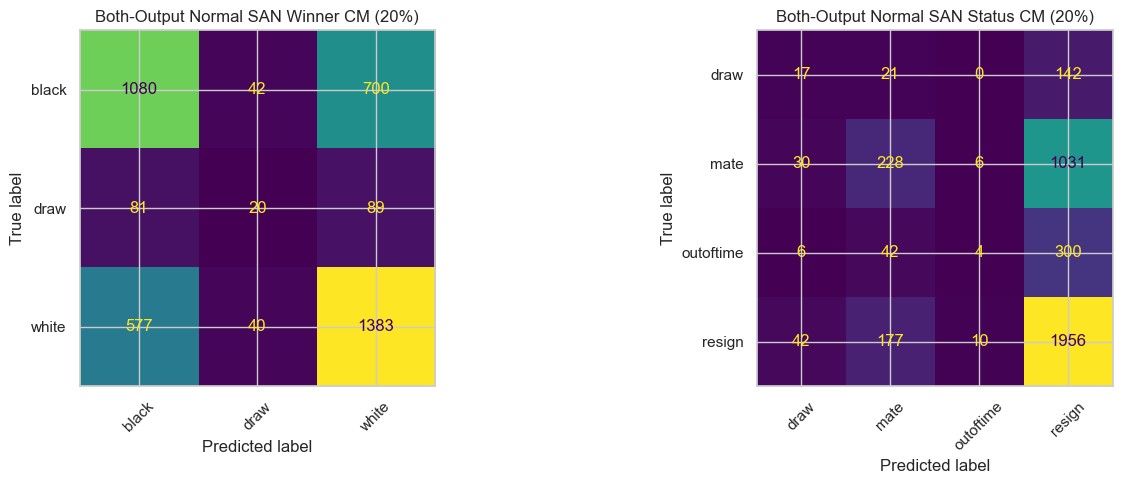


Both-Output Normal SAN TEST RESULTS AT 40% OF GAME

--- Both-Output Normal SAN Winner at 40% ---
Accuracy : 0.6304
Precision: 0.6221
Recall   : 0.6304
F1       : 0.6257

Classification Report:
              precision    recall  f1-score   support

       black       0.63      0.63      0.63      1822
        draw       0.21      0.13      0.16       190
       white       0.66      0.68      0.67      2000

    accuracy                           0.63      4012
   macro avg       0.50      0.48      0.48      4012
weighted avg       0.62      0.63      0.63      4012


--- Both-Output Normal SAN Status at 40% ---
Accuracy : 0.5426
Precision: 0.4975
Recall   : 0.5426
F1       : 0.5042

Classification Report:
              precision    recall  f1-score   support

        draw       0.21      0.12      0.15       180
        mate       0.47      0.32      0.38      1295
   outoftime       0.19      0.05      0.08       352
      resign       0.59      0.79      0.67      2185

    accurac

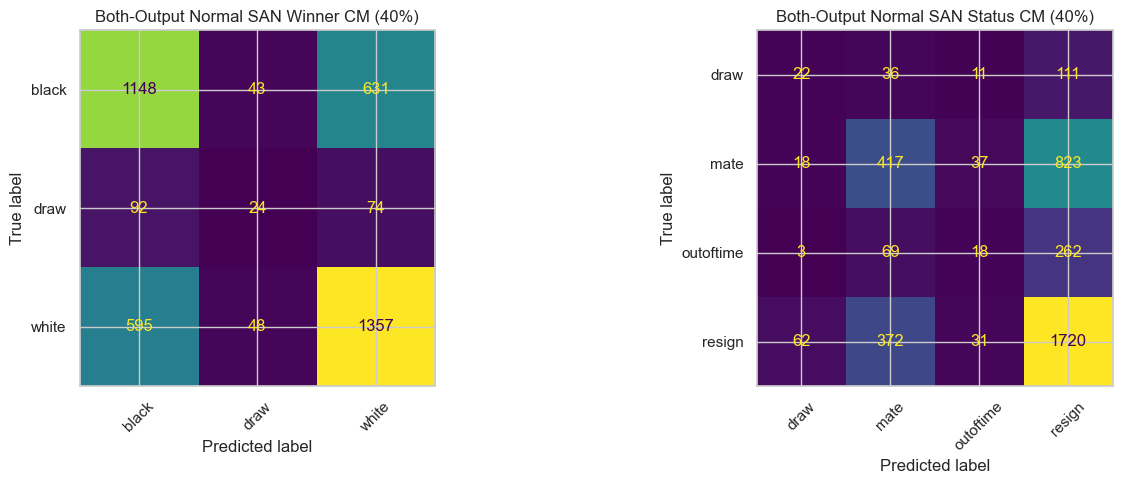


Both-Output Normal SAN TEST RESULTS AT 60% OF GAME

--- Both-Output Normal SAN Winner at 60% ---
Accuracy : 0.6742
Precision: 0.6654
Recall   : 0.6742
F1       : 0.6690

Classification Report:
              precision    recall  f1-score   support

       black       0.68      0.66      0.67      1822
        draw       0.22      0.14      0.17       190
       white       0.69      0.74      0.72      2000

    accuracy                           0.67      4012
   macro avg       0.53      0.51      0.52      4012
weighted avg       0.67      0.67      0.67      4012


--- Both-Output Normal SAN Status at 60% ---
Accuracy : 0.5284
Precision: 0.5049
Recall   : 0.5284
F1       : 0.5144

Classification Report:
              precision    recall  f1-score   support

        draw       0.22      0.12      0.16       180
        mate       0.46      0.44      0.45      1295
   outoftime       0.17      0.11      0.13       352
      resign       0.61      0.68      0.64      2185

    accurac

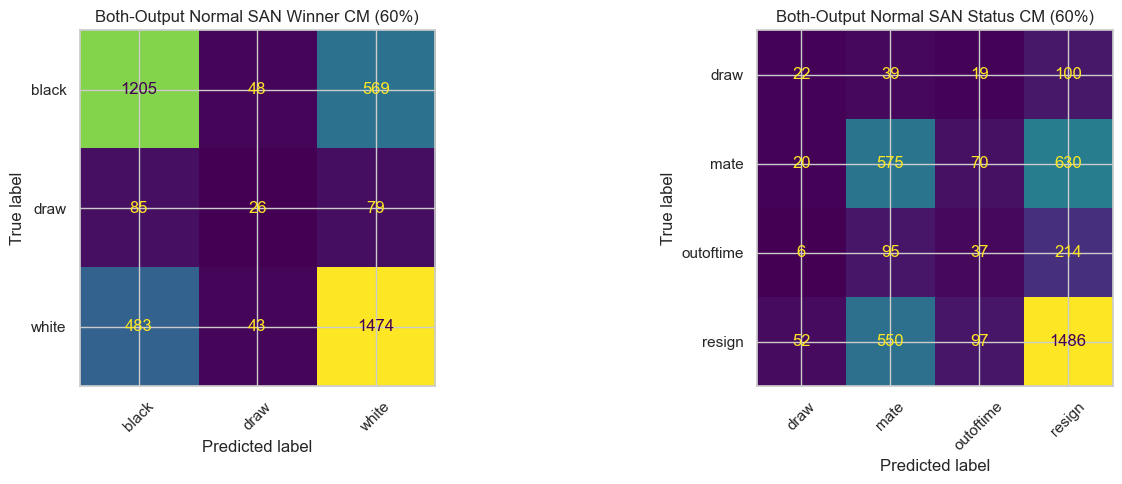


Both-Output Normal SAN TEST RESULTS AT 80% OF GAME

--- Both-Output Normal SAN Winner at 80% ---
Accuracy : 0.7193
Precision: 0.7090
Recall   : 0.7193
F1       : 0.7133

Classification Report:
              precision    recall  f1-score   support

       black       0.73      0.73      0.73      1822
        draw       0.25      0.14      0.18       190
       white       0.74      0.77      0.75      2000

    accuracy                           0.72      4012
   macro avg       0.57      0.54      0.55      4012
weighted avg       0.71      0.72      0.71      4012


--- Both-Output Normal SAN Status at 80% ---
Accuracy : 0.5259
Precision: 0.5371
Recall   : 0.5259
F1       : 0.5271

Classification Report:
              precision    recall  f1-score   support

        draw       0.24      0.13      0.17       180
        mate       0.46      0.58      0.51      1295
   outoftime       0.15      0.17      0.16       352
      resign       0.67      0.59      0.62      2185

    accurac

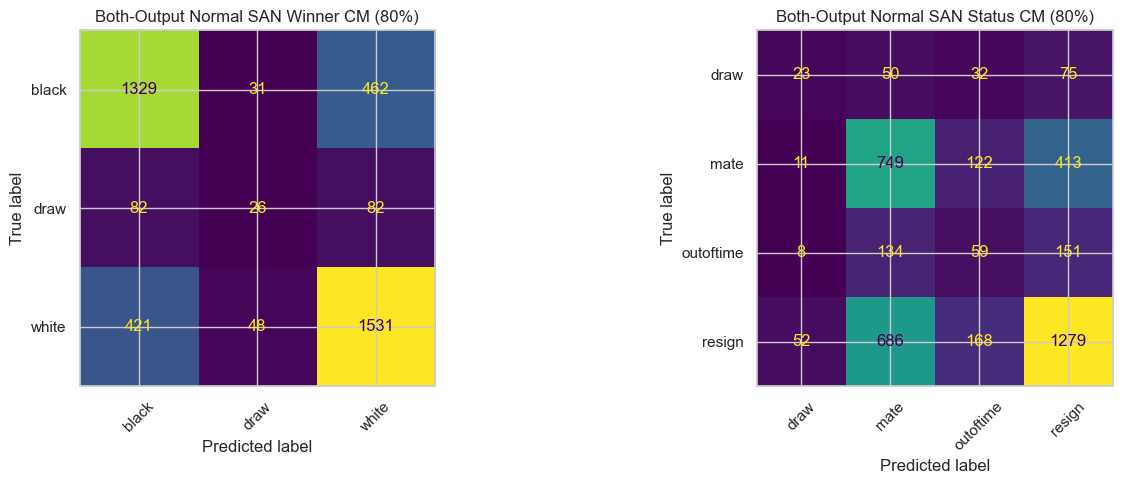


Both-Output Normal SAN TEST RESULTS AT 95% OF GAME

--- Both-Output Normal SAN Winner at 95% ---
Accuracy : 0.7722
Precision: 0.7619
Recall   : 0.7722
F1       : 0.7661

Classification Report:
              precision    recall  f1-score   support

       black       0.79      0.78      0.78      1822
        draw       0.28      0.16      0.20       190
       white       0.79      0.82      0.80      2000

    accuracy                           0.77      4012
   macro avg       0.62      0.59      0.60      4012
weighted avg       0.76      0.77      0.77      4012


--- Both-Output Normal SAN Status at 95% ---
Accuracy : 0.5204
Precision: 0.5598
Recall   : 0.5204
F1       : 0.5234

Classification Report:
              precision    recall  f1-score   support

        draw       0.31      0.14      0.20       180
        mate       0.47      0.69      0.55      1295
   outoftime       0.13      0.16      0.15       352
      resign       0.70      0.51      0.59      2185

    accurac

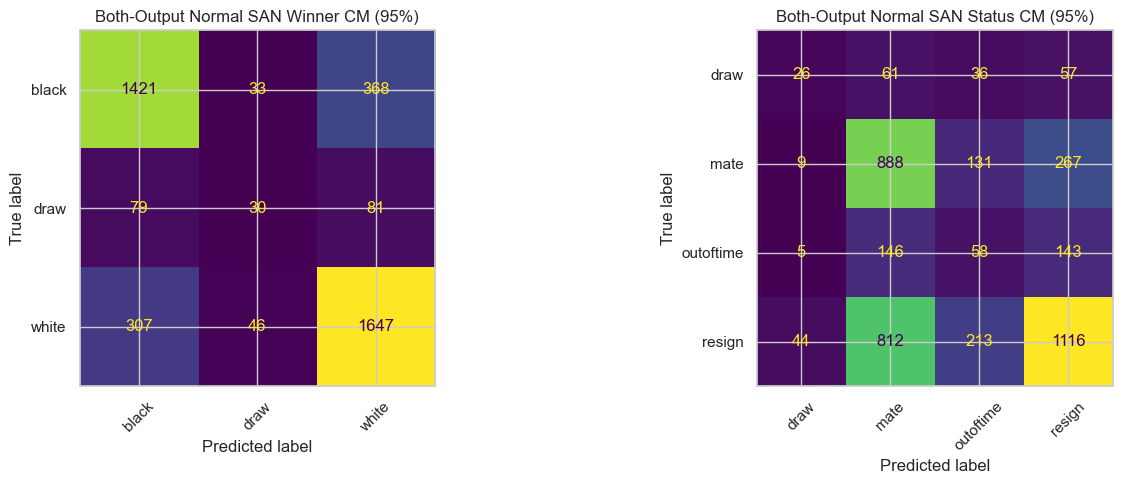


Both-Output Subtokenized SAN TEST RESULTS AT 20% OF GAME

--- Both-Output Subtokenized SAN Winner at 20% ---
Accuracy : 0.6254
Precision: 0.6086
Recall   : 0.6254
F1       : 0.6143

Classification Report:
              precision    recall  f1-score   support

       black       0.62      0.60      0.61      1822
        draw       0.17      0.04      0.07       190
       white       0.64      0.70      0.67      2000

    accuracy                           0.63      4012
   macro avg       0.48      0.45      0.45      4012
weighted avg       0.61      0.63      0.61      4012


--- Both-Output Subtokenized SAN Status at 20% ---
Accuracy : 0.5518
Precision: 0.4725
Recall   : 0.5518
F1       : 0.4506

Classification Report:
              precision    recall  f1-score   support

        draw       0.20      0.03      0.06       180
        mate       0.49      0.13      0.21      1295
   outoftime       0.00      0.00      0.00       352
      resign       0.56      0.93      0.70     

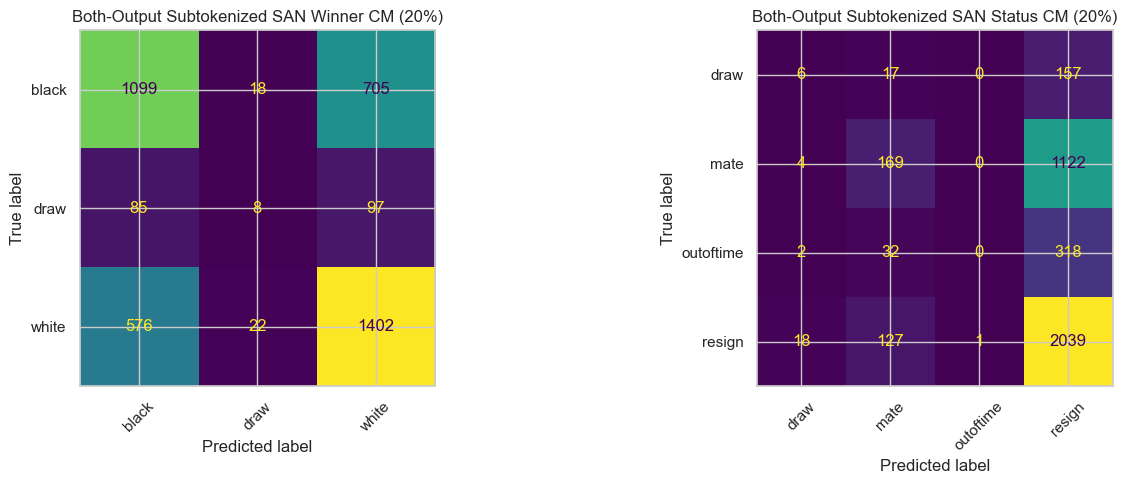


Both-Output Subtokenized SAN TEST RESULTS AT 40% OF GAME

--- Both-Output Subtokenized SAN Winner at 40% ---
Accuracy : 0.6366
Precision: 0.6243
Recall   : 0.6366
F1       : 0.6282

Classification Report:
              precision    recall  f1-score   support

       black       0.62      0.64      0.63      1822
        draw       0.25      0.08      0.13       190
       white       0.66      0.68      0.67      2000

    accuracy                           0.64      4012
   macro avg       0.51      0.47      0.48      4012
weighted avg       0.62      0.64      0.63      4012


--- Both-Output Subtokenized SAN Status at 40% ---
Accuracy : 0.5576
Precision: 0.4817
Recall   : 0.5576
F1       : 0.4894

Classification Report:
              precision    recall  f1-score   support

        draw       0.27      0.07      0.11       180
        mate       0.48      0.25      0.33      1295
   outoftime       0.00      0.00      0.00       352
      resign       0.58      0.87      0.69     

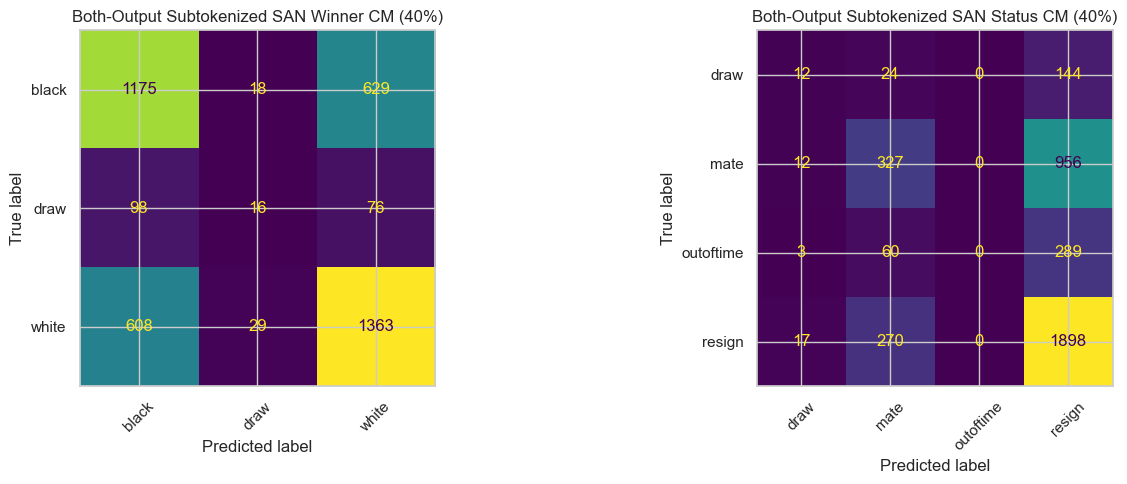


Both-Output Subtokenized SAN TEST RESULTS AT 60% OF GAME

--- Both-Output Subtokenized SAN Winner at 60% ---
Accuracy : 0.6735
Precision: 0.6716
Recall   : 0.6735
F1       : 0.6725

Classification Report:
              precision    recall  f1-score   support

       black       0.68      0.68      0.68      1822
        draw       0.23      0.21      0.22       190
       white       0.71      0.71      0.71      2000

    accuracy                           0.67      4012
   macro avg       0.54      0.53      0.54      4012
weighted avg       0.67      0.67      0.67      4012


--- Both-Output Subtokenized SAN Status at 60% ---
Accuracy : 0.5583
Precision: 0.5050
Recall   : 0.5583
F1       : 0.5207

Classification Report:
              precision    recall  f1-score   support

        draw       0.25      0.23      0.24       180
        mate       0.49      0.39      0.43      1295
   outoftime       0.08      0.00      0.01       352
      resign       0.61      0.78      0.68     

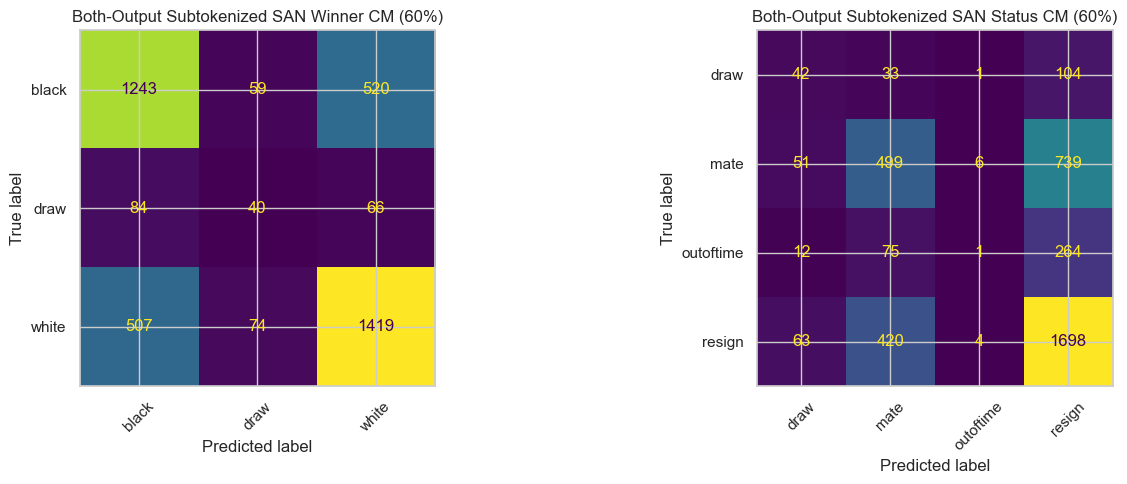


Both-Output Subtokenized SAN TEST RESULTS AT 80% OF GAME

--- Both-Output Subtokenized SAN Winner at 80% ---
Accuracy : 0.7089
Precision: 0.7209
Recall   : 0.7089
F1       : 0.7139

Classification Report:
              precision    recall  f1-score   support

       black       0.72      0.73      0.73      1822
        draw       0.27      0.40      0.32       190
       white       0.76      0.72      0.74      2000

    accuracy                           0.71      4012
   macro avg       0.58      0.62      0.60      4012
weighted avg       0.72      0.71      0.71      4012


--- Both-Output Subtokenized SAN Status at 80% ---
Accuracy : 0.5606
Precision: 0.5424
Recall   : 0.5606
F1       : 0.5421

Classification Report:
              precision    recall  f1-score   support

        draw       0.25      0.43      0.31       180
        mate       0.49      0.55      0.51      1295
   outoftime       0.20      0.01      0.02       352
      resign       0.65      0.67      0.66     

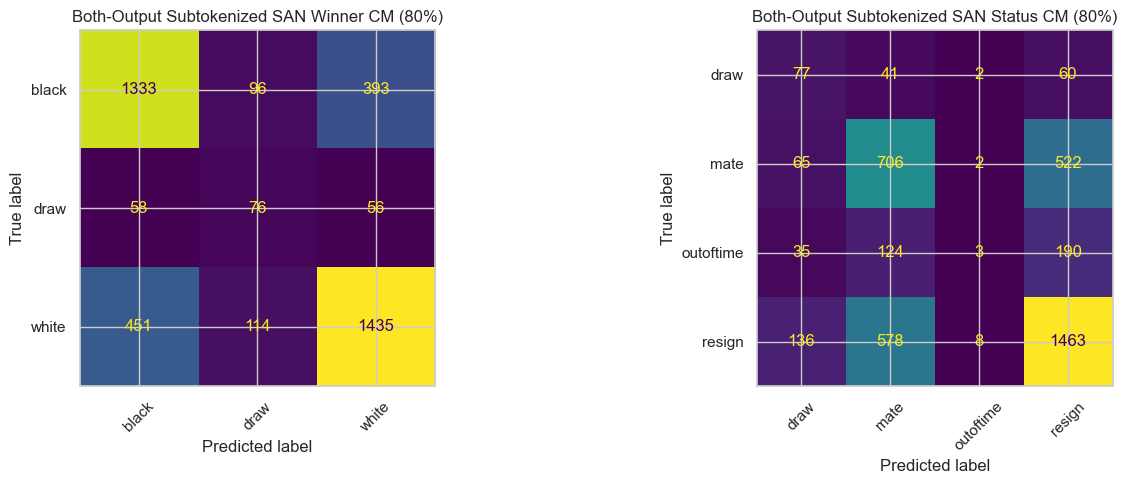


Both-Output Subtokenized SAN TEST RESULTS AT 95% OF GAME

--- Both-Output Subtokenized SAN Winner at 95% ---
Accuracy : 0.7590
Precision: 0.7732
Recall   : 0.7590
F1       : 0.7648

Classification Report:
              precision    recall  f1-score   support

       black       0.79      0.76      0.77      1822
        draw       0.31      0.51      0.39       190
       white       0.80      0.78      0.79      2000

    accuracy                           0.76      4012
   macro avg       0.63      0.68      0.65      4012
weighted avg       0.77      0.76      0.76      4012


--- Both-Output Subtokenized SAN Status at 95% ---
Accuracy : 0.5399
Precision: 0.5586
Recall   : 0.5399
F1       : 0.5267

Classification Report:
              precision    recall  f1-score   support

        draw       0.28      0.56      0.38       180
        mate       0.46      0.66      0.54      1295
   outoftime       0.32      0.03      0.05       352
      resign       0.68      0.55      0.61     

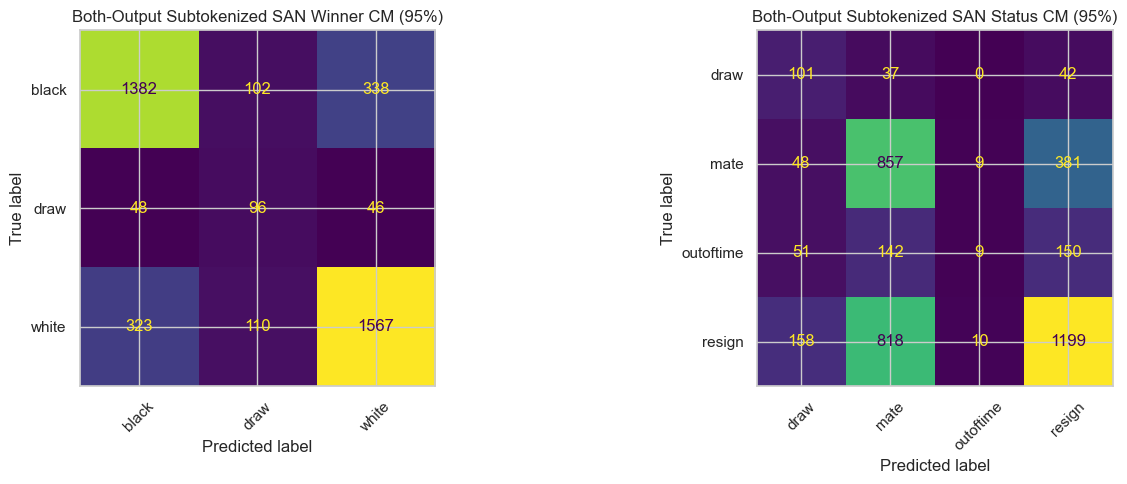


Winner-Only Normal SAN TEST RESULTS AT 20% OF GAME

--- Winner-Only Normal SAN Winner at 20% ---
Accuracy : 0.6236
Precision: 0.6143
Recall   : 0.6236
F1       : 0.6176

Classification Report:
              precision    recall  f1-score   support

       black       0.63      0.60      0.62      1822
        draw       0.21      0.12      0.15       190
       white       0.64      0.69      0.66      2000

    accuracy                           0.62      4012
   macro avg       0.49      0.47      0.48      4012
weighted avg       0.61      0.62      0.62      4012



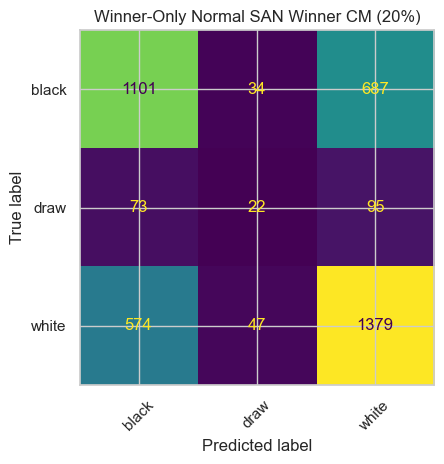


Winner-Only Normal SAN TEST RESULTS AT 40% OF GAME

--- Winner-Only Normal SAN Winner at 40% ---
Accuracy : 0.6261
Precision: 0.6181
Recall   : 0.6261
F1       : 0.6216

Classification Report:
              precision    recall  f1-score   support

       black       0.63      0.62      0.63      1822
        draw       0.18      0.12      0.14       190
       white       0.65      0.68      0.66      2000

    accuracy                           0.63      4012
   macro avg       0.49      0.47      0.48      4012
weighted avg       0.62      0.63      0.62      4012



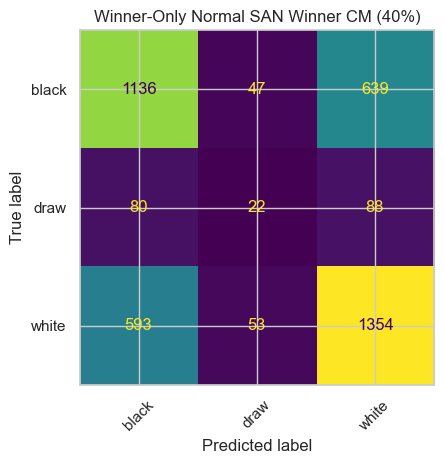


Winner-Only Normal SAN TEST RESULTS AT 60% OF GAME

--- Winner-Only Normal SAN Winner at 60% ---
Accuracy : 0.6665
Precision: 0.6578
Recall   : 0.6665
F1       : 0.6609

Classification Report:
              precision    recall  f1-score   support

       black       0.68      0.65      0.66      1822
        draw       0.24      0.14      0.18       190
       white       0.68      0.74      0.71      2000

    accuracy                           0.67      4012
   macro avg       0.53      0.51      0.52      4012
weighted avg       0.66      0.67      0.66      4012



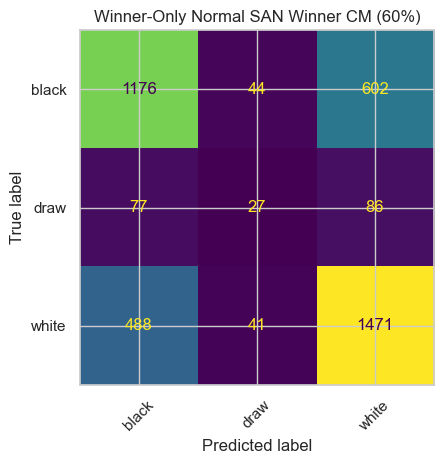


Winner-Only Normal SAN TEST RESULTS AT 80% OF GAME

--- Winner-Only Normal SAN Winner at 80% ---
Accuracy : 0.7046
Precision: 0.6956
Recall   : 0.7046
F1       : 0.6990

Classification Report:
              precision    recall  f1-score   support

       black       0.72      0.69      0.71      1822
        draw       0.22      0.14      0.17       190
       white       0.72      0.77      0.74      2000

    accuracy                           0.70      4012
   macro avg       0.55      0.53      0.54      4012
weighted avg       0.70      0.70      0.70      4012



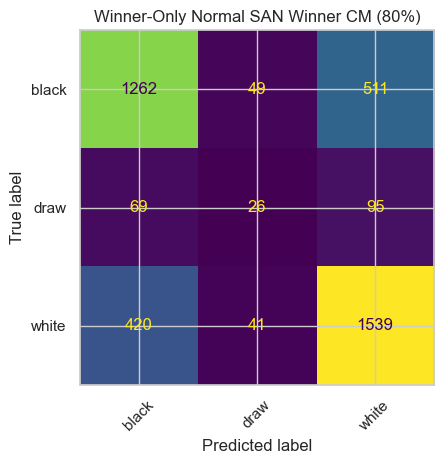


Winner-Only Normal SAN TEST RESULTS AT 95% OF GAME

--- Winner-Only Normal SAN Winner at 95% ---
Accuracy : 0.7565
Precision: 0.7463
Recall   : 0.7565
F1       : 0.7495

Classification Report:
              precision    recall  f1-score   support

       black       0.78      0.74      0.76      1822
        draw       0.29      0.15      0.20       190
       white       0.76      0.83      0.79      2000

    accuracy                           0.76      4012
   macro avg       0.61      0.57      0.58      4012
weighted avg       0.75      0.76      0.75      4012



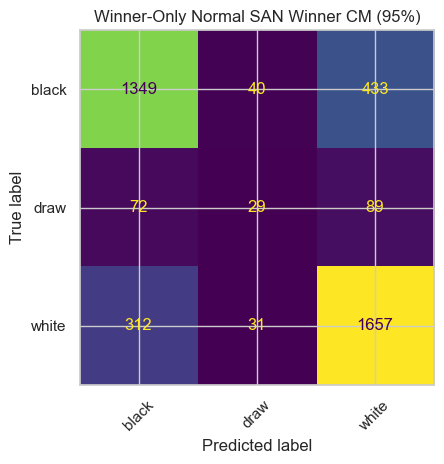


Winner-Only Subtokenized SAN TEST RESULTS AT 20% OF GAME

--- Winner-Only Subtokenized SAN Winner at 20% ---
Accuracy : 0.6251
Precision: 0.6179
Recall   : 0.6251
F1       : 0.6093

Classification Report:
              precision    recall  f1-score   support

       black       0.63      0.56      0.60      1822
        draw       0.45      0.03      0.05       190
       white       0.62      0.74      0.68      2000

    accuracy                           0.63      4012
   macro avg       0.57      0.44      0.44      4012
weighted avg       0.62      0.63      0.61      4012



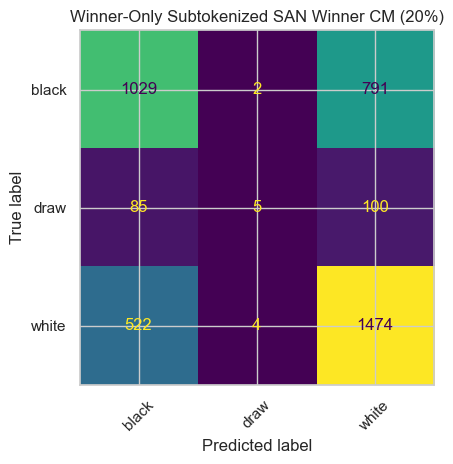


Winner-Only Subtokenized SAN TEST RESULTS AT 40% OF GAME

--- Winner-Only Subtokenized SAN Winner at 40% ---
Accuracy : 0.6353
Precision: 0.6204
Recall   : 0.6353
F1       : 0.6235

Classification Report:
              precision    recall  f1-score   support

       black       0.63      0.62      0.62      1822
        draw       0.26      0.05      0.08       190
       white       0.65      0.71      0.68      2000

    accuracy                           0.64      4012
   macro avg       0.51      0.46      0.46      4012
weighted avg       0.62      0.64      0.62      4012



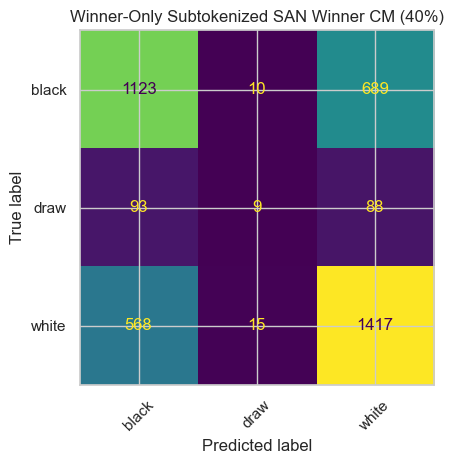


Winner-Only Subtokenized SAN TEST RESULTS AT 60% OF GAME

--- Winner-Only Subtokenized SAN Winner at 60% ---
Accuracy : 0.6830
Precision: 0.6739
Recall   : 0.6830
F1       : 0.6774

Classification Report:
              precision    recall  f1-score   support

       black       0.69      0.68      0.68      1822
        draw       0.26      0.15      0.19       190
       white       0.70      0.74      0.72      2000

    accuracy                           0.68      4012
   macro avg       0.55      0.52      0.53      4012
weighted avg       0.67      0.68      0.68      4012



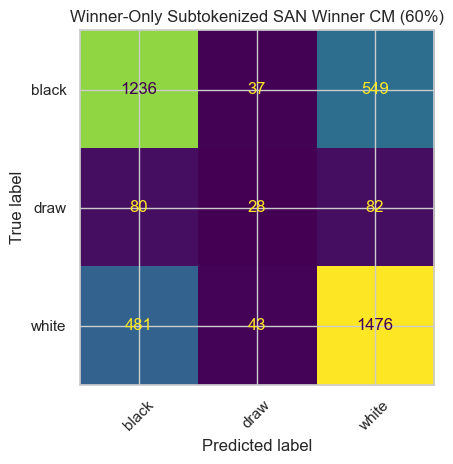


Winner-Only Subtokenized SAN TEST RESULTS AT 80% OF GAME

--- Winner-Only Subtokenized SAN Winner at 80% ---
Accuracy : 0.7154
Precision: 0.7193
Recall   : 0.7154
F1       : 0.7172

Classification Report:
              precision    recall  f1-score   support

       black       0.73      0.72      0.72      1822
        draw       0.28      0.34      0.31       190
       white       0.75      0.75      0.75      2000

    accuracy                           0.72      4012
   macro avg       0.59      0.60      0.59      4012
weighted avg       0.72      0.72      0.72      4012



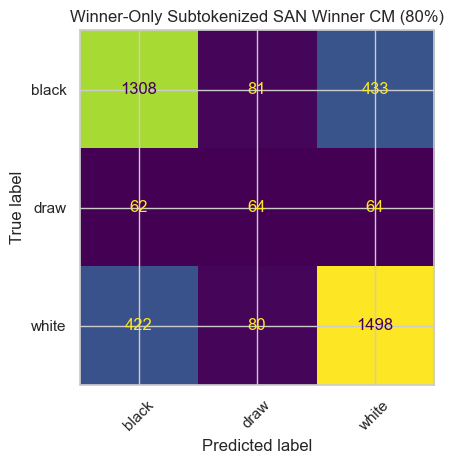


Winner-Only Subtokenized SAN TEST RESULTS AT 95% OF GAME

--- Winner-Only Subtokenized SAN Winner at 95% ---
Accuracy : 0.7679
Precision: 0.7742
Recall   : 0.7679
F1       : 0.7707

Classification Report:
              precision    recall  f1-score   support

       black       0.79      0.77      0.78      1822
        draw       0.35      0.45      0.39       190
       white       0.80      0.80      0.80      2000

    accuracy                           0.77      4012
   macro avg       0.65      0.67      0.66      4012
weighted avg       0.77      0.77      0.77      4012



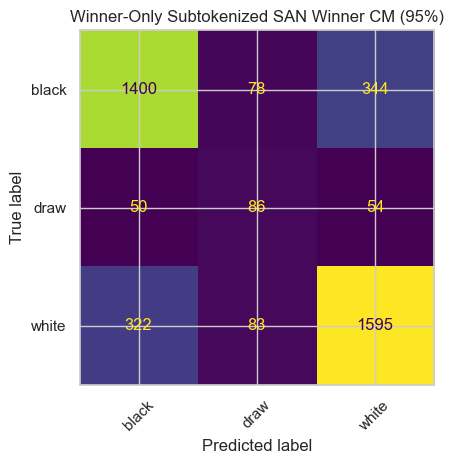


Status-Only Normal SAN TEST RESULTS AT 20% OF GAME

--- Status-Only Normal SAN Status at 20% ---
Accuracy : 0.5536
Precision: 0.4854
Recall   : 0.5536
F1       : 0.4310

Classification Report:
              precision    recall  f1-score   support

        draw       0.33      0.01      0.02       180
        mate       0.52      0.08      0.14      1295
   outoftime       0.00      0.00      0.00       352
      resign       0.56      0.97      0.71      2185

    accuracy                           0.55      4012
   macro avg       0.35      0.27      0.22      4012
weighted avg       0.49      0.55      0.43      4012



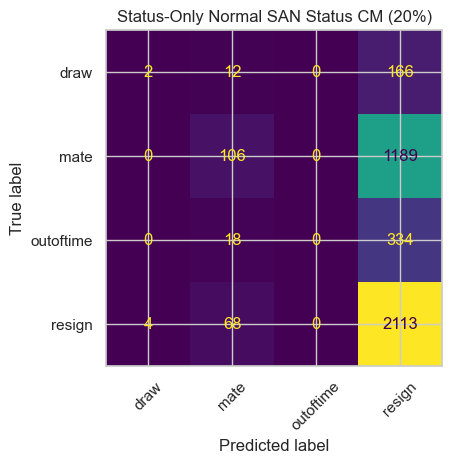


Status-Only Normal SAN TEST RESULTS AT 40% OF GAME

--- Status-Only Normal SAN Status at 40% ---
Accuracy : 0.5606
Precision: 0.4747
Recall   : 0.5606
F1       : 0.4674

Classification Report:
              precision    recall  f1-score   support

        draw       0.00      0.00      0.00       180
        mate       0.51      0.18      0.26      1295
   outoftime       0.00      0.00      0.00       352
      resign       0.57      0.92      0.70      2185

    accuracy                           0.56      4012
   macro avg       0.27      0.28      0.24      4012
weighted avg       0.47      0.56      0.47      4012



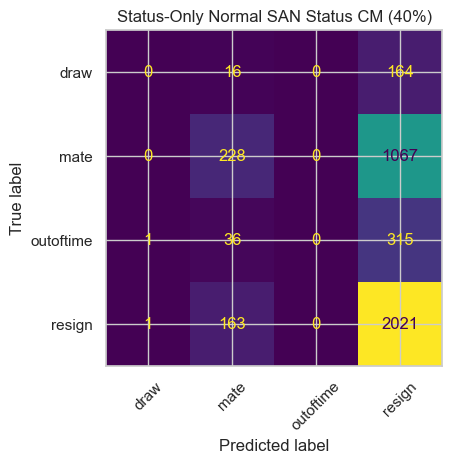


Status-Only Normal SAN TEST RESULTS AT 60% OF GAME

--- Status-Only Normal SAN Status at 60% ---
Accuracy : 0.5705
Precision: 0.4924
Recall   : 0.5705
F1       : 0.5058

Classification Report:
              precision    recall  f1-score   support

        draw       0.17      0.01      0.01       180
        mate       0.52      0.31      0.39      1295
   outoftime       0.00      0.00      0.00       352
      resign       0.58      0.86      0.70      2185

    accuracy                           0.57      4012
   macro avg       0.32      0.30      0.27      4012
weighted avg       0.49      0.57      0.51      4012



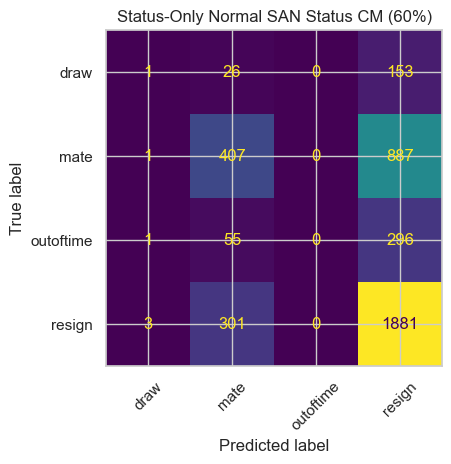


Status-Only Normal SAN TEST RESULTS AT 80% OF GAME

--- Status-Only Normal SAN Status at 80% ---
Accuracy : 0.5785
Precision: 0.5117
Recall   : 0.5785
F1       : 0.5364

Classification Report:
              precision    recall  f1-score   support

        draw       0.32      0.08      0.13       180
        mate       0.50      0.46      0.48      1295
   outoftime       0.00      0.00      0.00       352
      resign       0.62      0.78      0.69      2185

    accuracy                           0.58      4012
   macro avg       0.36      0.33      0.33      4012
weighted avg       0.51      0.58      0.54      4012



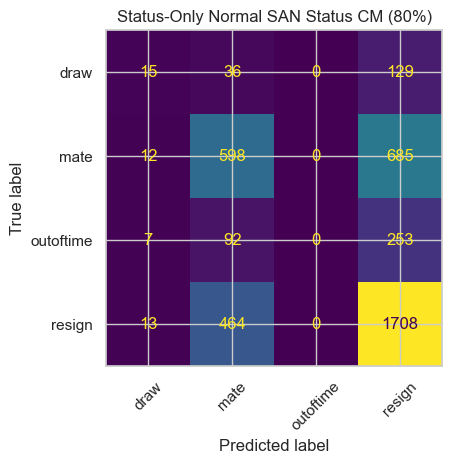


Status-Only Normal SAN TEST RESULTS AT 95% OF GAME

--- Status-Only Normal SAN Status at 95% ---
Accuracy : 0.5805
Precision: 0.5261
Recall   : 0.5805
F1       : 0.5480

Classification Report:
              precision    recall  f1-score   support

        draw       0.34      0.11      0.16       180
        mate       0.50      0.62      0.55      1295
   outoftime       0.00      0.00      0.00       352
      resign       0.64      0.69      0.67      2185

    accuracy                           0.58      4012
   macro avg       0.37      0.35      0.34      4012
weighted avg       0.53      0.58      0.55      4012



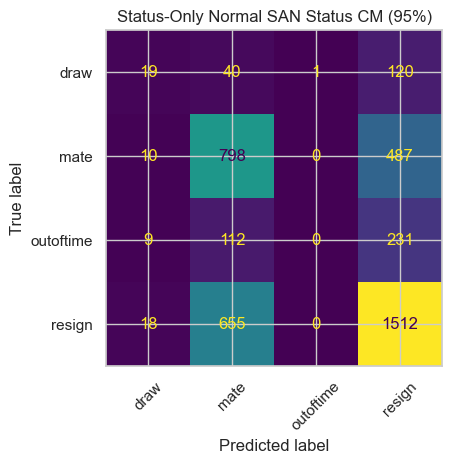


Status-Only Subtokenized SAN TEST RESULTS AT 20% OF GAME

--- Status-Only Subtokenized SAN Status at 20% ---
Accuracy : 0.5598
Precision: 0.4843
Recall   : 0.5598
F1       : 0.4886

Classification Report:
              precision    recall  f1-score   support

        draw       0.00      0.00      0.00       180
        mate       0.48      0.26      0.34      1295
   outoftime       0.17      0.00      0.01       352
      resign       0.58      0.87      0.70      2185

    accuracy                           0.56      4012
   macro avg       0.31      0.28      0.26      4012
weighted avg       0.48      0.56      0.49      4012



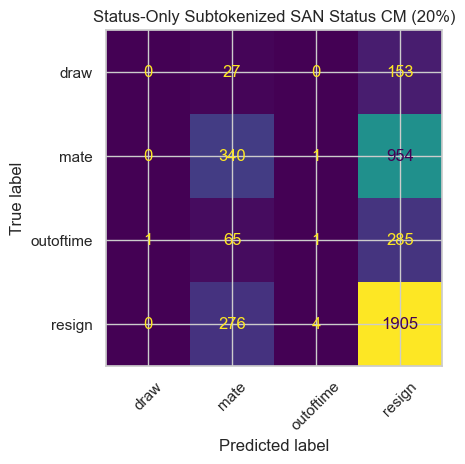


Status-Only Subtokenized SAN TEST RESULTS AT 40% OF GAME

--- Status-Only Subtokenized SAN Status at 40% ---
Accuracy : 0.5436
Precision: 0.5247
Recall   : 0.5436
F1       : 0.4942

Classification Report:
              precision    recall  f1-score   support

        draw       0.50      0.03      0.05       180
        mate       0.44      0.36      0.40      1295
   outoftime       0.50      0.00      0.01       352
      resign       0.58      0.78      0.67      2185

    accuracy                           0.54      4012
   macro avg       0.50      0.29      0.28      4012
weighted avg       0.52      0.54      0.49      4012



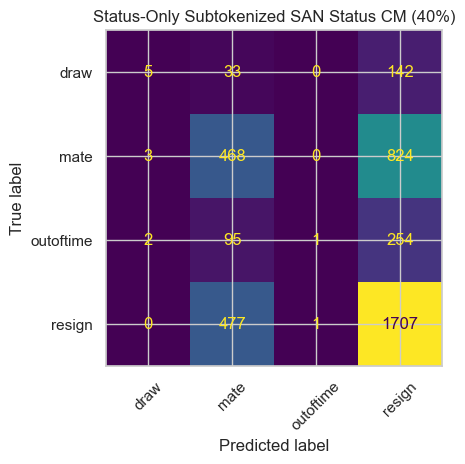


Status-Only Subtokenized SAN TEST RESULTS AT 60% OF GAME

--- Status-Only Subtokenized SAN Status at 60% ---
Accuracy : 0.5523
Precision: 0.5173
Recall   : 0.5523
F1       : 0.5219

Classification Report:
              precision    recall  f1-score   support

        draw       0.23      0.15      0.18       180
        mate       0.46      0.48      0.47      1295
   outoftime       0.25      0.00      0.01       352
      resign       0.62      0.71      0.66      2185

    accuracy                           0.55      4012
   macro avg       0.39      0.34      0.33      4012
weighted avg       0.52      0.55      0.52      4012



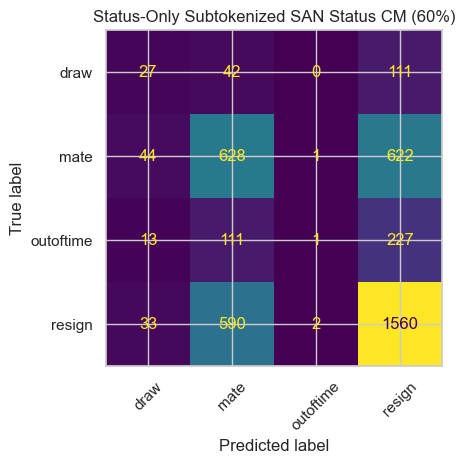


Status-Only Subtokenized SAN TEST RESULTS AT 80% OF GAME

--- Status-Only Subtokenized SAN Status at 80% ---
Accuracy : 0.5476
Precision: 0.5401
Recall   : 0.5476
F1       : 0.5304

Classification Report:
              precision    recall  f1-score   support

        draw       0.21      0.36      0.27       180
        mate       0.47      0.58      0.52      1295
   outoftime       0.25      0.00      0.01       352
      resign       0.66      0.63      0.64      2185

    accuracy                           0.55      4012
   macro avg       0.40      0.39      0.36      4012
weighted avg       0.54      0.55      0.53      4012



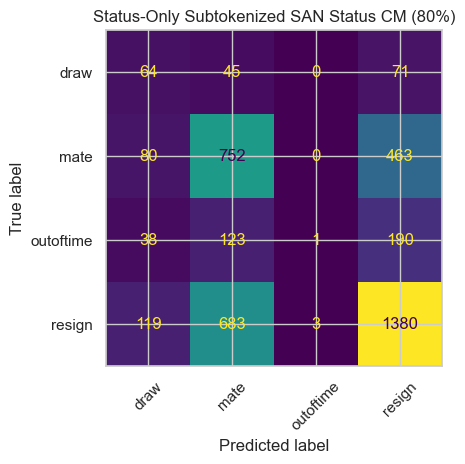


Status-Only Subtokenized SAN TEST RESULTS AT 95% OF GAME

--- Status-Only Subtokenized SAN Status at 95% ---
Accuracy : 0.5356
Precision: 0.5762
Recall   : 0.5356
F1       : 0.5203

Classification Report:
              precision    recall  f1-score   support

        draw       0.25      0.52      0.34       180
        mate       0.46      0.68      0.55      1295
   outoftime       0.50      0.01      0.01       352
      resign       0.68      0.53      0.60      2185

    accuracy                           0.54      4012
   macro avg       0.47      0.44      0.37      4012
weighted avg       0.58      0.54      0.52      4012



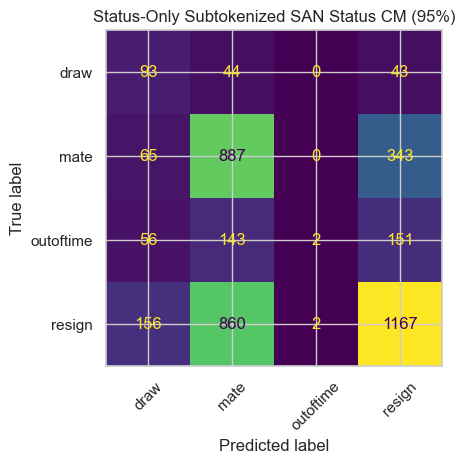

,model,representation,target,progress,progress_percent,accuracy,precision,recall,f1
0,Both-Output Normal SAN,normal,winner,0.20,20.0,0.618893,0.608907,0.618893,0.612536
1,Both-Output Normal SAN,normal,status,0.20,20.0,0.549601,0.493493,0.549601,0.470426
2,Both-Output Normal SAN,normal,winner,0.40,40.0,0.630359,0.622063,0.630359,0.625650
3,Both-Output Normal SAN,normal,status,0.40,40.0,0.542622,0.497482,0.542622,0.504217
4,Both-Output Normal SAN,normal,winner,0.60,60.0,0.674227,0.665449,0.674227,0.668988
5,Both-Output Normal SAN,normal,status,0.60,60.0,0.528415,0.504891,0.528415,0.514408
6,Both-Output Normal SAN,normal,winner,0.80,80.0,0.719342,0.708987,0.719342,0.713279
7,Both-Output Normal SAN,normal,status,0.80,80.0,0.525922,0.537065,0.525922,0.527127
8,Both-Output Normal SAN,normal,winner,0.95,95.0,0.772183,0.761878,0.772183,0.766052
9,Both-Output Normal SAN,normal,status,0.95,95.0,0.520439,0.559758,0.520439,0.523359


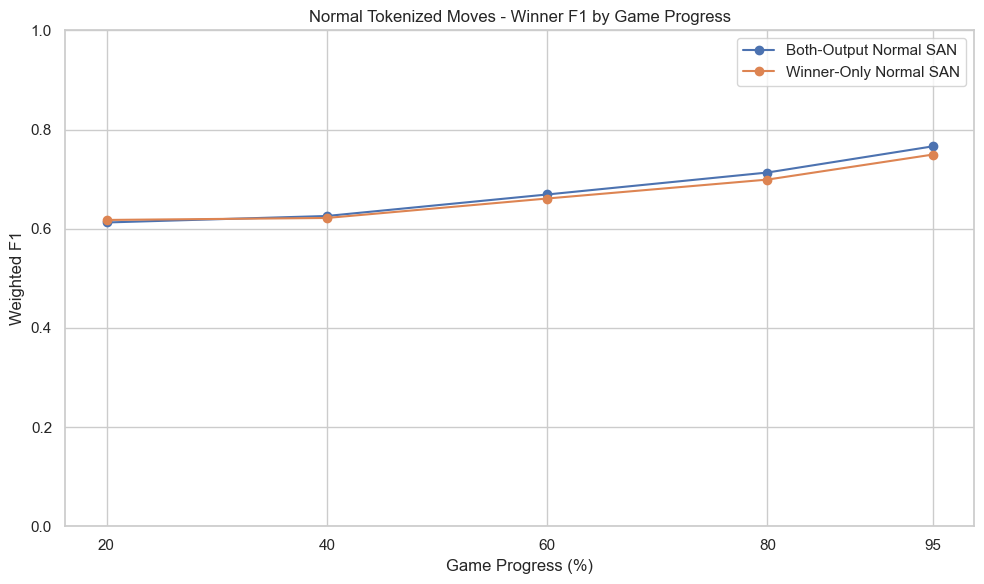

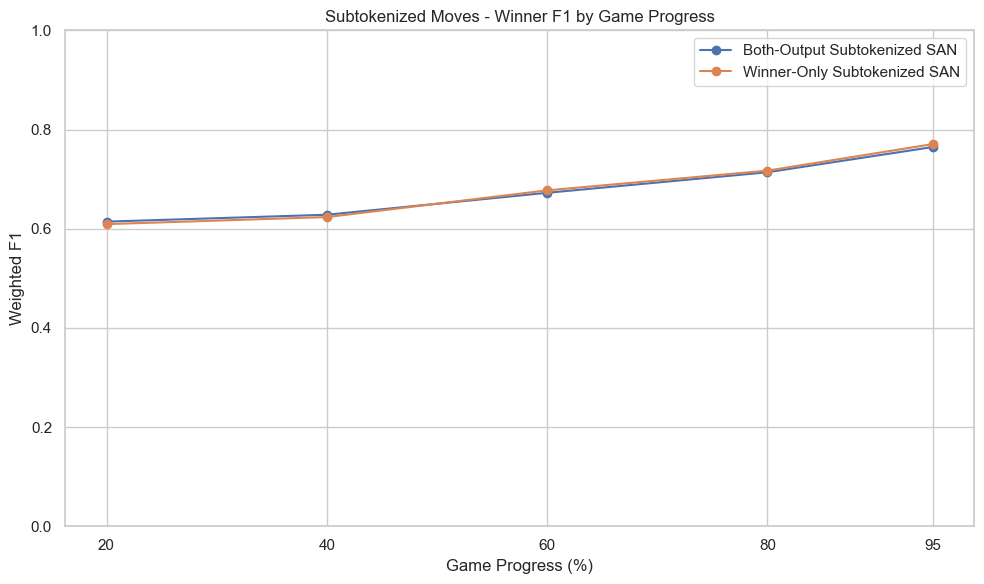

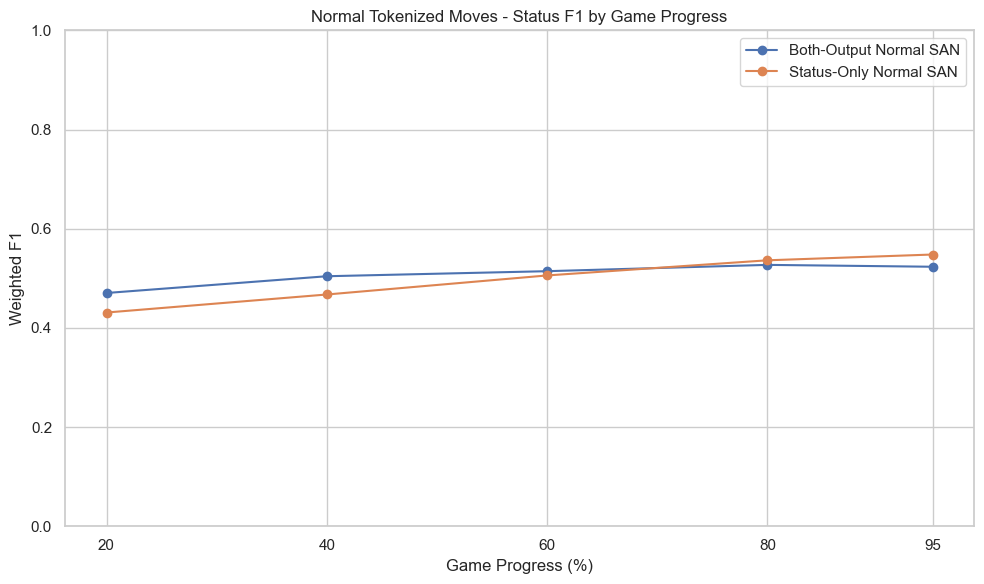

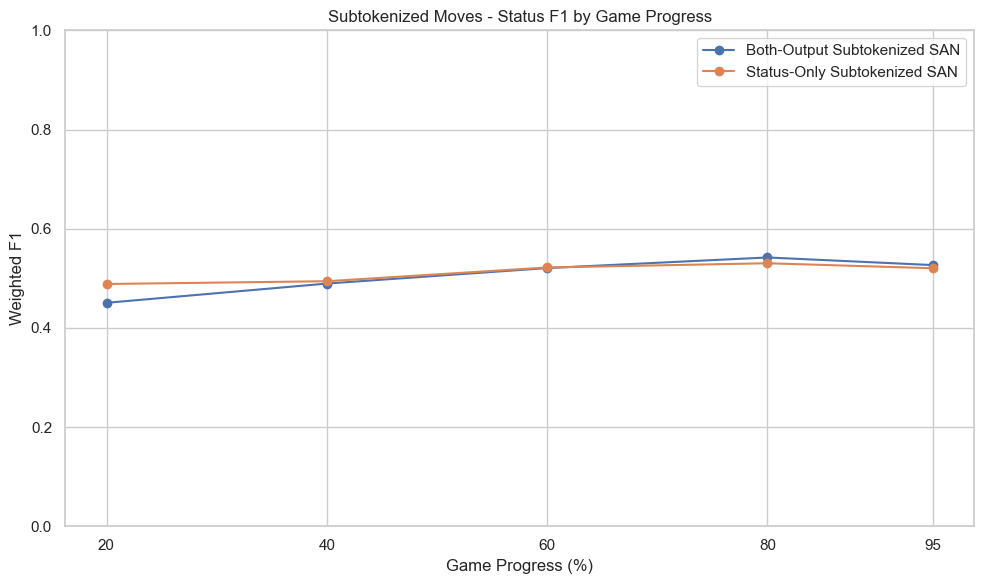

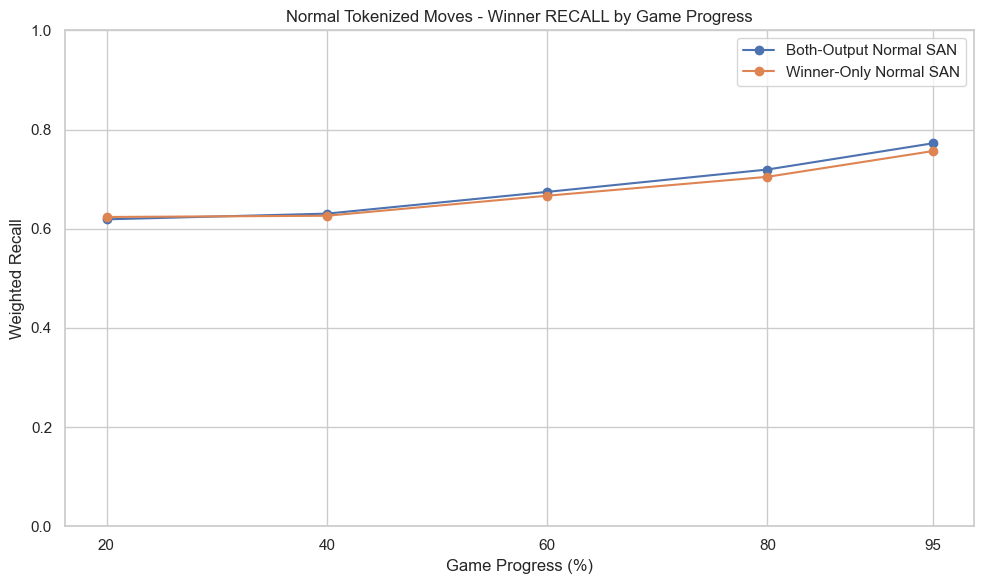

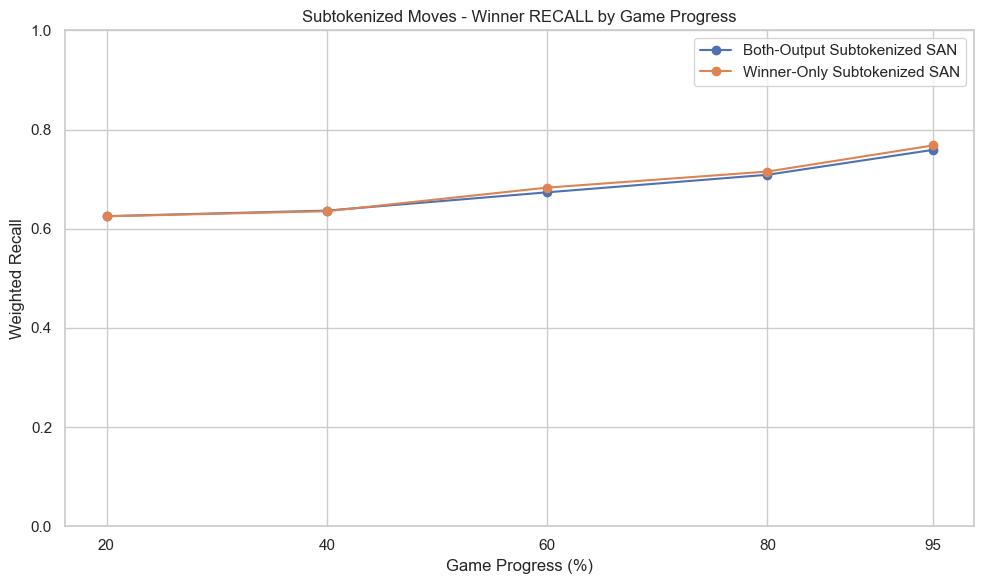

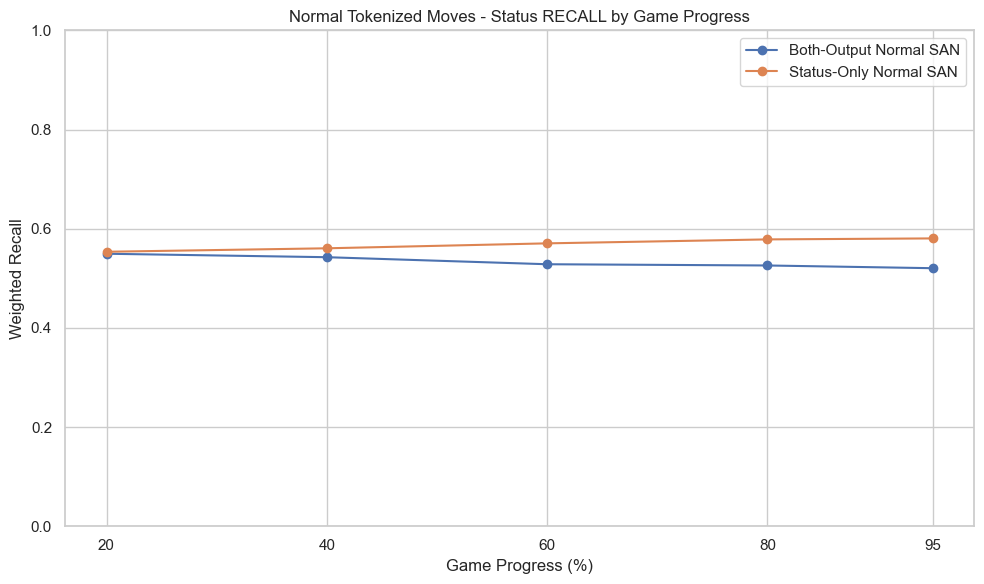

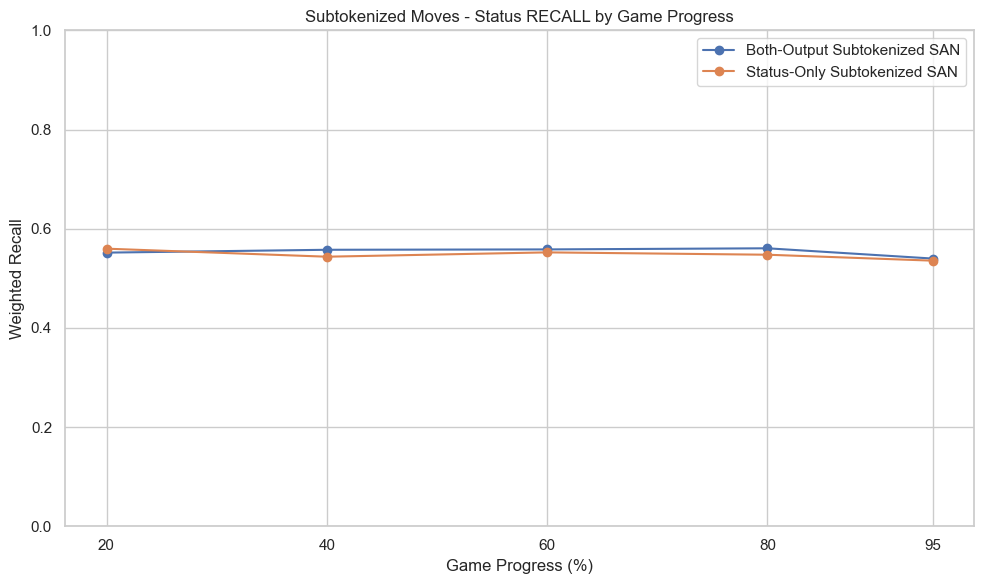

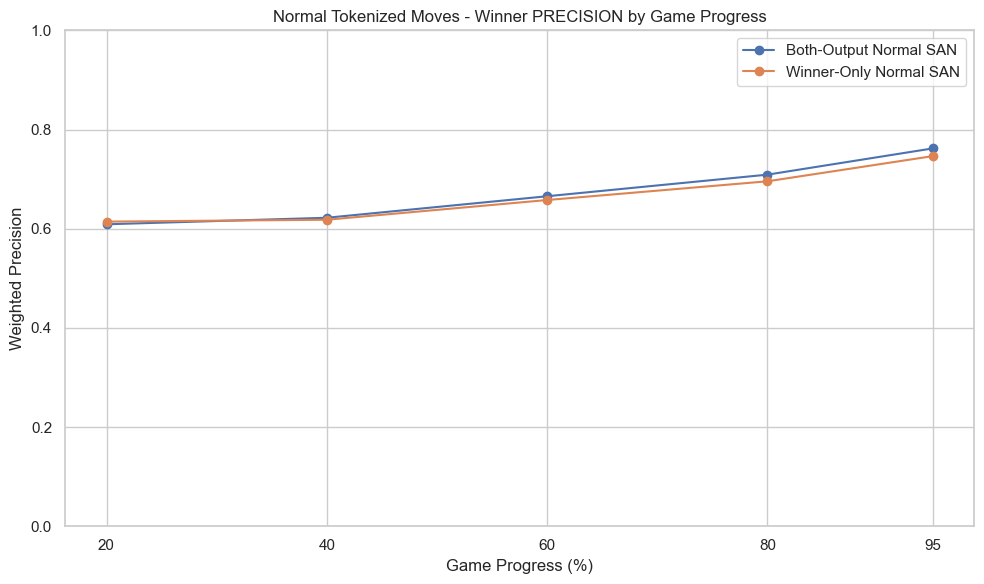

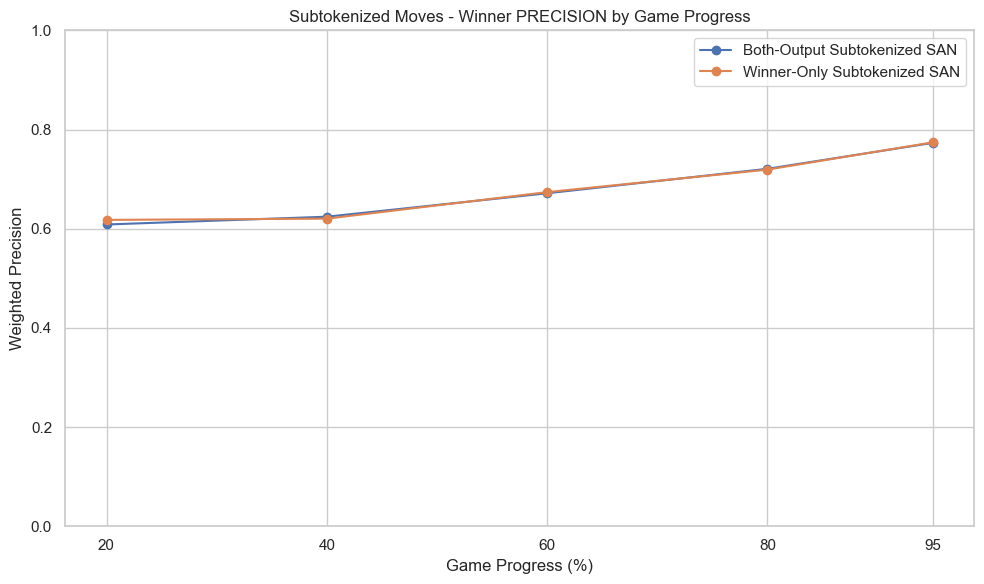

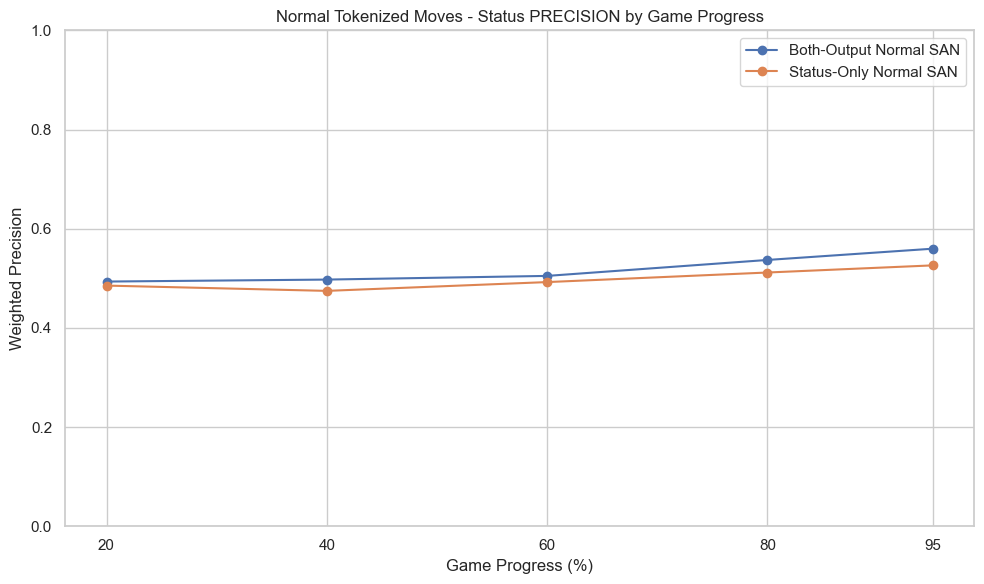

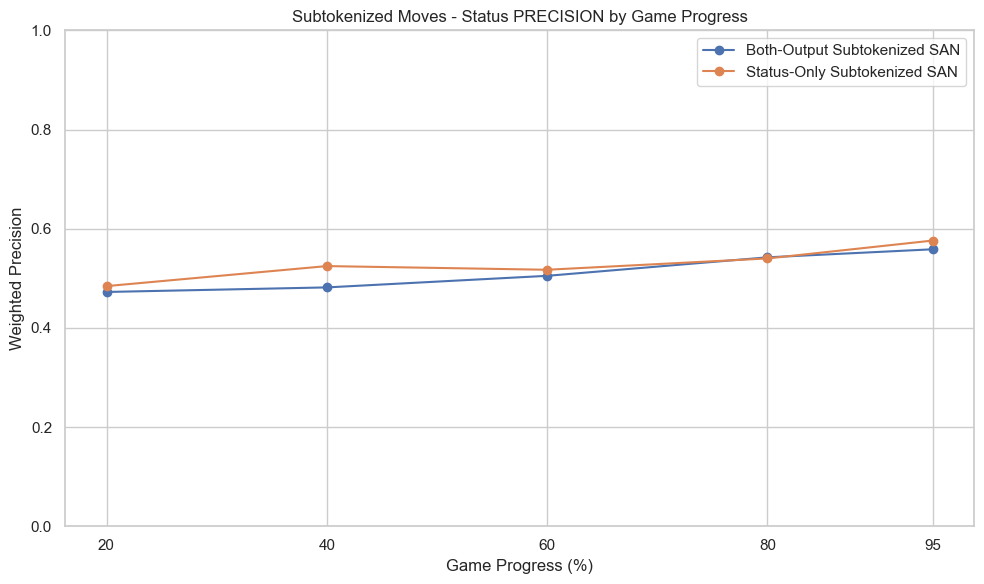

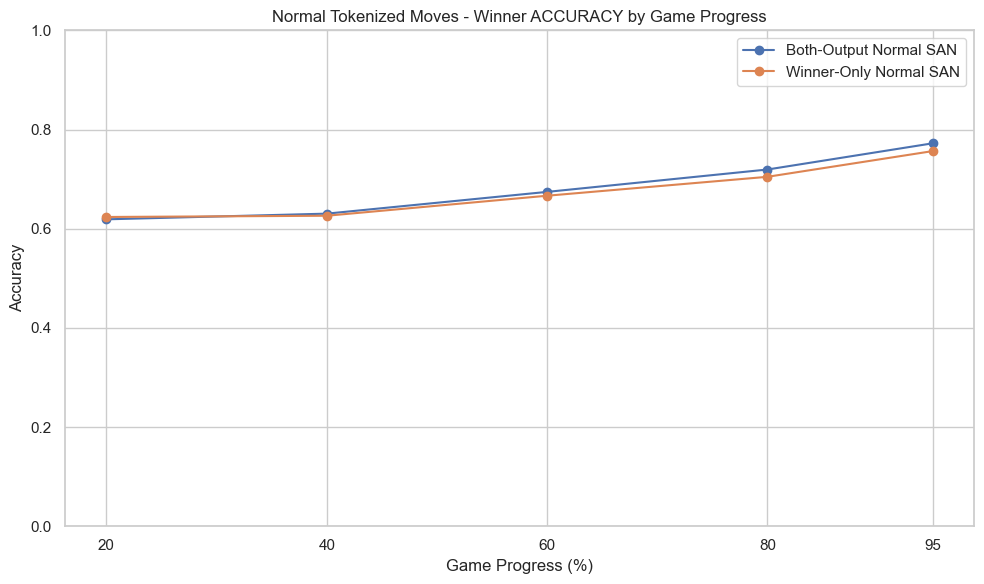

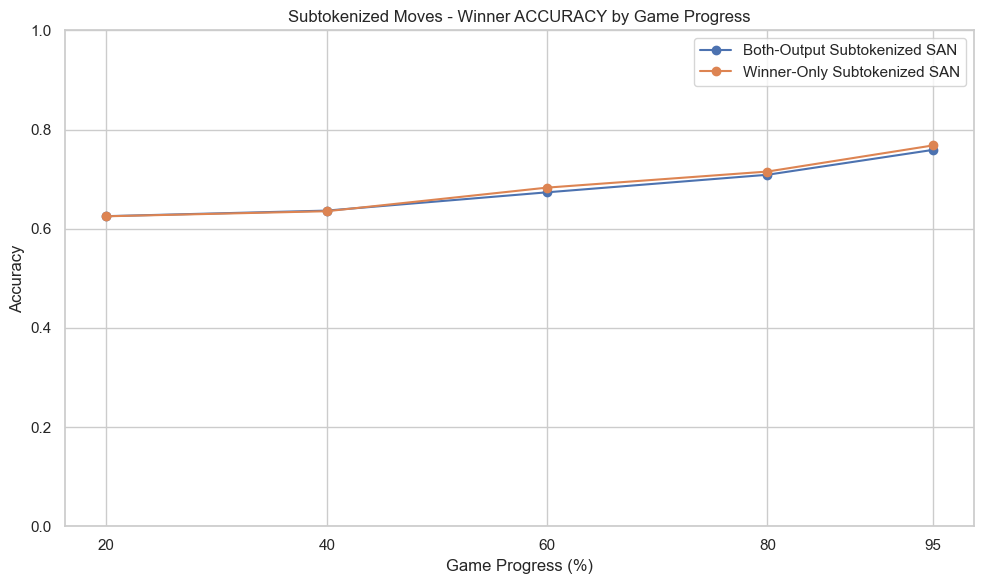

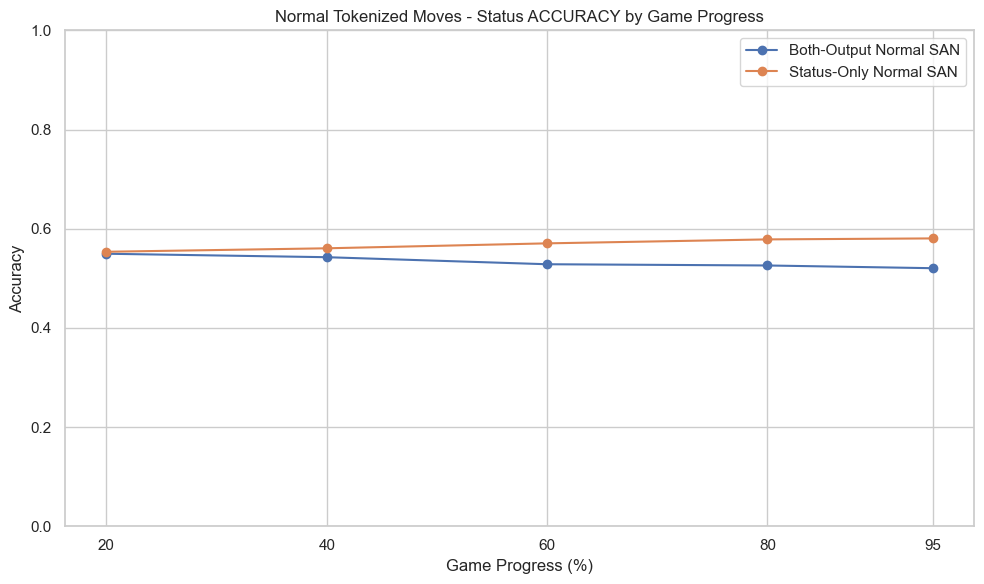

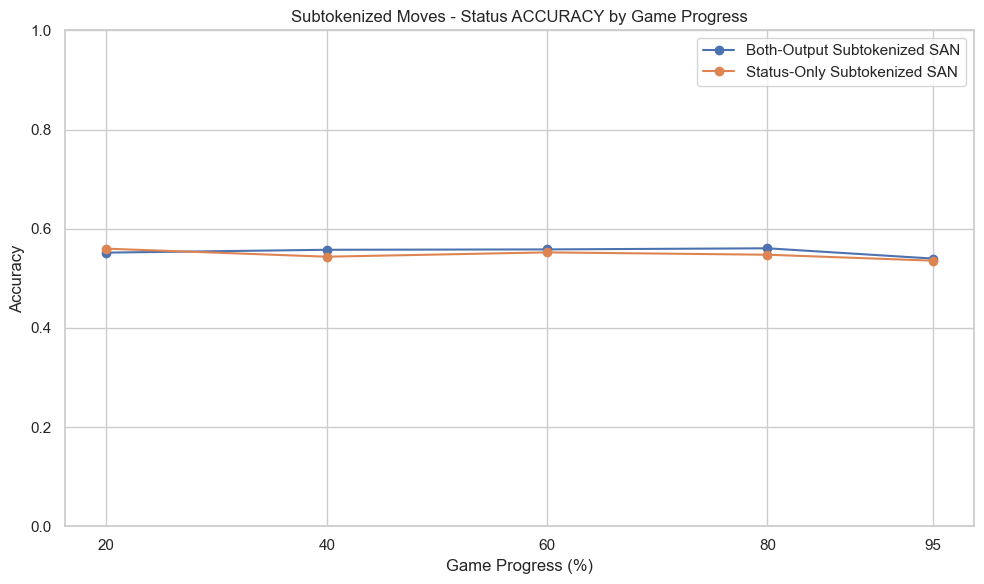

In [17]:
def plot_transformer_metric_progress(results_df, representation, target, metric, title=None):
    plot_df = results_df[
        (results_df["representation"] == representation) &
        (results_df["target"] == target)
    ].copy()

    plt.figure(figsize=(10, 6))

    for model_name in plot_df["model"].unique():
        model_df = plot_df[plot_df["model"] == model_name].sort_values("progress_percent")

        plt.plot(
            model_df["progress_percent"],
            model_df[metric],
            marker="o",
            label=model_name
        )

    plt.xlabel("Game Progress (%)")
    plt.ylabel(f"Weighted {metric.capitalize()}" if metric != "accuracy" else "Accuracy")
    plt.ylim(0, 1)
    plt.xticks([20, 40, 60, 80, 95])

    if title is None:
        title = f"{representation} {target} {metric} by Game Progress"

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def get_weighted_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

def build_transformer_phase_data(progress_value, vectorizer, representation="subtok"):
    phase_df = test_expanded[np.isclose(test_expanded["progress"], progress_value)].copy()

    if len(phase_df) == 0:
        return phase_df, None, None, None, None

    if representation == "subtok":
        phase_df["moves_eval"] = phase_df["moves_truncated"].apply(move_string_to_subtokens)
    elif representation == "normal":
        phase_df["moves_eval"] = phase_df["moves_truncated"].astype(str)
    else:
        raise ValueError("representation must be either 'normal' or 'subtok'")

    phase_move_text = phase_df["moves_eval"].astype(str).values
    X_moves_phase = vectorizer(phase_move_text).numpy()

    X_extra_phase = extra_scaler.transform(
        phase_df[feature_cols].astype(float)
    ).astype(np.float32)

    y_winner_phase = phase_df["y_winner"].values
    y_status_phase = phase_df["y_status"].values

    return phase_df, X_moves_phase, X_extra_phase, y_winner_phase, y_status_phase


def print_transformer_metrics(y_true, y_pred, model_name, class_names):
    print(f"\n--- {model_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

transformer_results = []

def evaluate_transformer_at_progress(
    progress_value,
    model,
    vectorizer,
    representation,
    model_label,
    output_type="both",
    make_confusion_matrix=True
):
    phase_df, X_moves_phase, X_extra_phase, y_winner_phase, y_status_phase = (
        build_transformer_phase_data(
            progress_value,
            vectorizer=vectorizer,
            representation=representation
        )
    )

    if len(phase_df) == 0:
        print(f"No test samples found at progress={progress_value}")
        return

    preds = model.predict(
        {
            "moves_input": X_moves_phase,
            "extra_input": X_extra_phase
        },
        verbose=0
    )

    print("\n" + "=" * 70)
    print(f"{model_label} TEST RESULTS AT {int(progress_value * 100)}% OF GAME")
    print("=" * 70)

    if output_type == "winner":
        winner_pred = np.argmax(preds, axis=1)

        winner_f1 = f1_score(
            y_winner_phase,
            winner_pred,
            average="weighted",
            zero_division=0
        )

        winner_metrics = get_weighted_metrics(y_winner_phase, winner_pred)

        transformer_results.append({
            "model": model_label,
            "representation": representation,
            "target": "winner",
            "progress": progress_value,
            "progress_percent": progress_value * 100,
            **winner_metrics
        })

        print_transformer_metrics(
            y_winner_phase,
            winner_pred,
            f"{model_label} Winner at {int(progress_value * 100)}%",
            winner_encoder.classes_
        )

        if make_confusion_matrix:
            disp = ConfusionMatrixDisplay(
                confusion_matrix=confusion_matrix(y_winner_phase, winner_pred),
                display_labels=winner_encoder.classes_
            )
            disp.plot(colorbar=False)
            plt.title(f"{model_label} Winner CM ({int(progress_value * 100)}%)")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    elif output_type == "status":
        status_pred = np.argmax(preds, axis=1)

        status_f1 = f1_score(
            y_status_phase,
            status_pred,
            average="weighted",
            zero_division=0
        )

        status_metrics = get_weighted_metrics(y_status_phase, status_pred)

        transformer_results.append({
            "model": model_label,
            "representation": representation,
            "target": "status",
            "progress": progress_value,
            "progress_percent": progress_value * 100,
            **status_metrics
        })

        print_transformer_metrics(
            y_status_phase,
            status_pred,
            f"{model_label} Status at {int(progress_value * 100)}%",
            status_encoder.classes_
        )

        if make_confusion_matrix:
            disp = ConfusionMatrixDisplay(
                confusion_matrix=confusion_matrix(y_status_phase, status_pred),
                display_labels=status_encoder.classes_
            )
            disp.plot(colorbar=False)
            plt.title(f"{model_label} Status CM ({int(progress_value * 100)}%)")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    elif output_type == "both":
        winner_pred_probs, status_pred_probs = preds

        winner_pred = np.argmax(winner_pred_probs, axis=1)
        status_pred = np.argmax(status_pred_probs, axis=1)

        winner_f1 = f1_score(
            y_winner_phase,
            winner_pred,
            average="weighted",
            zero_division=0
        )

        status_f1 = f1_score(
            y_status_phase,
            status_pred,
            average="weighted",
            zero_division=0
        )

        winner_metrics = get_weighted_metrics(y_winner_phase, winner_pred)
        status_metrics = get_weighted_metrics(y_status_phase, status_pred)

        transformer_results.append({
            "model": model_label,
            "representation": representation,
            "target": "winner",
            "progress": progress_value,
            "progress_percent": progress_value * 100,
            **winner_metrics
        })

        transformer_results.append({
            "model": model_label,
            "representation": representation,
            "target": "status",
            "progress": progress_value,
            "progress_percent": progress_value * 100,
            **status_metrics
        })


        print_transformer_metrics(
            y_winner_phase,
            winner_pred,
            f"{model_label} Winner at {int(progress_value * 100)}%",
            winner_encoder.classes_
        )

        print_transformer_metrics(
            y_status_phase,
            status_pred,
            f"{model_label} Status at {int(progress_value * 100)}%",
            status_encoder.classes_
        )

        if make_confusion_matrix:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            winner_disp = ConfusionMatrixDisplay(
                confusion_matrix=confusion_matrix(y_winner_phase, winner_pred),
                display_labels=winner_encoder.classes_
            )
            winner_disp.plot(ax=axes[0], colorbar=False)
            axes[0].set_title(f"{model_label} Winner CM ({int(progress_value * 100)}%)")
            axes[0].tick_params(axis="x", rotation=45)

            status_disp = ConfusionMatrixDisplay(
                confusion_matrix=confusion_matrix(y_status_phase, status_pred),
                display_labels=status_encoder.classes_
            )
            status_disp.plot(ax=axes[1], colorbar=False)
            axes[1].set_title(f"{model_label} Status CM ({int(progress_value * 100)}%)")
            axes[1].tick_params(axis="x", rotation=45)

            plt.tight_layout()
            plt.show()

    else:
        raise ValueError("output_type must be 'winner', 'status', or 'both'")
    



progress_points_to_test = [0.2, 0.4, 0.6, 0.8, 0.95]

transformer_results = []

models_to_evaluate = [
    {
        "model": both_model_normal,
        "vectorizer": normal_vectorizer,
        "representation": "normal",
        "label": "Both-Output Normal SAN",
        "output_type": "both"
    },
    {
        "model": both_model_subtok,
        "vectorizer": subtok_vectorizer,
        "representation": "subtok",
        "label": "Both-Output Subtokenized SAN",
        "output_type": "both"
    },
    {
        "model": winner_model_normal,
        "vectorizer": normal_vectorizer,
        "representation": "normal",
        "label": "Winner-Only Normal SAN",
        "output_type": "winner"
    },
    {
        "model": winner_model_subtok,
        "vectorizer": subtok_vectorizer,
        "representation": "subtok",
        "label": "Winner-Only Subtokenized SAN",
        "output_type": "winner"
    },
    {
        "model": status_model_normal,
        "vectorizer": normal_vectorizer,
        "representation": "normal",
        "label": "Status-Only Normal SAN",
        "output_type": "status"
    },
    {
        "model": status_model_subtok,
        "vectorizer": subtok_vectorizer,
        "representation": "subtok",
        "label": "Status-Only Subtokenized SAN",
        "output_type": "status"
    },
]

for model_info in models_to_evaluate:
    for progress in progress_points_to_test:
        evaluate_transformer_at_progress(
            progress_value=progress,
            model=model_info["model"],
            vectorizer=model_info["vectorizer"],
            representation=model_info["representation"],
            model_label=model_info["label"],
            output_type=model_info["output_type"],
            make_confusion_matrix=True
        )


results_df = pd.DataFrame(transformer_results)

results_df["progress_percent"] = results_df["progress"] * 100

display(results_df)
metrics_to_plot = ["f1", "recall", "precision", "accuracy"]

for metric in metrics_to_plot:
    plot_transformer_metric_progress(
        results_df,
        representation="normal",
        target="winner",
        metric=metric,
        title=f"Normal Tokenized Moves - Winner {metric.upper()} by Game Progress"
    )

    plot_transformer_metric_progress(
        results_df,
        representation="subtok",
        target="winner",
        metric=metric,
        title=f"Subtokenized Moves - Winner {metric.upper()} by Game Progress"
    )

    plot_transformer_metric_progress(
        results_df,
        representation="normal",
        target="status",
        metric=metric,
        title=f"Normal Tokenized Moves - Status {metric.upper()} by Game Progress"
    )

    plot_transformer_metric_progress(
        results_df,
        representation="subtok",
        target="status",
        metric=metric,
        title=f"Subtokenized Moves - Status {metric.upper()} by Game Progress"
    )